# TSL-ONE-S — Multimodal Thai Sign Language Recognition → Speech

**Goal.** Turn TSL-ONE-S skeletal `.npy` clips into recognised Thai Sign Language
glosses, reject signs outside the vocabulary, compose them into a Thai sentence,
and speak it.

**Pipeline (MSSF-Net).**

```
TSL-ONE-S .npy (T,75,2)
        │
   Preprocessing:  interpolate MediaPipe drop-outs → body-frame normalise → ΔX, Δ²X → resample to 64 frames
        │
 ┌──────┴───────┬────────────┬───────────────┐
 │              │            │               │
Left Hand   Right Hand     Pose         Face (coarse)
 MLP-LH       MLP-RH       MLP-P        Face Encoder
 └──────┬───────┴────────────┘               │
        │                              Face Temporal Encoder (BiGRU)
   Spatial Fusion → 256                      │ 128
        └───────────────┬────────────────────┘
                Cross-Modal Fusion (gated cross-attention)
                        │
             Temporal Transformer  (4 layers · d=256 · 8 heads)
                        │
                Attention Pooling → 256-D
             ┌──────────┴───────────┐
      Classification Head     Embedding Head (ArcFace)
        184 glosses             256-D metric space
             │                        │
        Known Sign          Prototype distance → Unknown ( `_` ) detection
                        │
             Gloss sequence → LLM → Thai sentence → TTS
```

**Ground rules used throughout**

| Rule | How it is enforced |
|---|---|
| No data leakage | Signer-independent split; audited on identity, filename **and** raw content hash (§5) |
| No test-set peeking | Standardiser, early stopping and the open-set threshold are fitted on train/val only |
| Efficiency first | Corpus held in RAM as contiguous float32; augmentation batched on GPU; no DataLoader workers |
| Minimal artefacts | Exactly one checkpoint is written to disk |

## 1 · Setup

In [1]:
import os, sys, json, time, warnings
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "modules").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from modules.config import CFG, ROOT as PROJ, DATA_DIR, TEST_DIR, ARTIFACT_DIR, get_device, set_seed
from modules import data_io, feature_engineering as fe, dataset as ds
from modules import models as M, train as T, evaluate as E, openset as OS, viz, inference as INF

FONT = viz.use_thai_font(11)
DEVICE = get_device()
set_seed(CFG.train.seed)
torch.backends.cudnn.benchmark = True

print(f"project      : {PROJ}")
print(f"python/torch : {sys.version.split()[0]} / {torch.__version__}")
print(f"device       : {DEVICE}"
      + (f"  ({torch.cuda.get_device_name(0)}, "
         f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)" if DEVICE.type=='cuda' else ""))
print(f"global font  : {FONT}  (Thai + Latin)")
print(f"openai key   : {'loaded from .env' if INF.load_openai_key() else 'NOT SET - LLM/TTS will fall back'}")

project      : D:\SLM-labs\SLM-Labs-TSONE
python/torch : 3.10.16 / 2.7.0+cu128
device       : cuda  (NVIDIA GeForce RTX 2050, 4.3 GB)
global font  : TH Sarabun New  (Thai + Latin)
openai key   : loaded from .env


In [2]:
# every tunable lives in modules/config.py
from dataclasses import asdict
print(json.dumps({"feature": asdict(CFG.feature), "aug": asdict(CFG.aug),
                  "model": asdict(CFG.model), "train": asdict(CFG.train)},
                 indent=1, default=str))

{
 "feature": {
  "n_frames": 64,
  "use_velocity": true,
  "use_acceleration": true,
  "smooth_window": 3,
  "eps": 1e-06
 },
 "aug": {
  "enabled": true,
  "rotate_deg": 10.0,
  "scale_range": [
   0.9,
   1.1
  ],
  "shift": 0.03,
  "noise_std": 0.008,
  "time_scale": [
   0.8,
   1.2
  ],
  "frame_drop_p": 0.05,
  "hand_drop_p": 0.05
 },
 "model": {
  "d_model": 256,
  "n_heads": 8,
  "n_layers": 4,
  "ff_mult": 4,
  "dropout": 0.2,
  "stream_hidden": 256,
  "face_dim": 128,
  "embed_dim": 256,
  "arc_scale": 24.0,
  "arc_margin": 0.2
 },
 "train": {
  "epochs": 150,
  "batch_size": 64,
  "lr": 0.0004,
  "weight_decay": 0.02,
  "warmup_epochs": 8,
  "label_smoothing": 0.1,
  "grad_clip": 1.0,
  "amp": true,
  "patience": 30,
  "embed_loss_w": 0.3,
  "seed": 42,
  "num_workers": 0
 }
}


## 2 · Extract / Load TSL-ONE-S

The release is already extracted to `.npy`. Each file is one isolated sign.

**Filename grammar** — `<signer>_<category>_<gloss>.npy`, e.g. `01_04_0133.npy`:
29 signers × 8 semantic categories × **184 gloss classes**.

**Array layout** — `(T, 150)` reshaped to `(T, 75, 2)`, MediaPipe *Holistic* order:

| index | block | landmarks |
|---|---|---|
| `0…32`  | Pose  | 33 (0–10 are face: nose, 6 eye pts, 2 ears, 2 mouth corners) |
| `33…53` | Left hand  | 21 |
| `54…74` | Right hand | 21 |

Coordinates are normalised image space; an exact `(0, 0)` is MediaPipe's
*"landmark not detected"* sentinel, **not** a real position.

In [3]:
df = data_io.build_index(DATA_DIR)
CLASS_NAMES = data_io.gloss_vocabulary(df)
N_CLASSES = len(CLASS_NAMES)

t0 = time.time()
clips = data_io.load_all(df, progress=False)
print(f"\n{len(df)} clips | {N_CLASSES} glosses | {df.signer.nunique()} signers "
      f"| {df.category.nunique()} categories | loaded in {time.time()-t0:.1f}s")
display(df.head(3)[["stem", "signer", "category", "gloss", "label"]])


4152 clips | 184 glosses | 29 signers | 8 categories | loaded in 2.4s


,stem,signer,category,gloss,label
0,01_01_0001,01,01,0001,0
1,01_01_0002,01,01,0002,1
2,01_01_0003,01,01,0003,2


## 3 · Inspect Raw Data (EDA)

In [4]:
df["n_frames"] = [len(c) for c in clips]
df["lh_missing"] = [float((c[:, 33:54] == 0).all(-1).all(-1).mean()) for c in clips]
df["rh_missing"] = [float((c[:, 54:75] == 0).all(-1).all(-1).mean()) for c in clips]

summary = pd.DataFrame({
    "clips":            [len(df)],
    "glosses":          [N_CLASSES],
    "signers":          [df.signer.nunique()],
    "frames min/med/max":[f"{df.n_frames.min()} / {int(df.n_frames.median())} / {df.n_frames.max()}"],
    "total frames":     [int(df.n_frames.sum())],
    "clips/gloss min-max":[f"{df.gloss.value_counts().min()}–{df.gloss.value_counts().max()}"],
    "left-hand frames missing":  [f"{df.lh_missing.mean()*100:.1f}%"],
    "right-hand frames missing": [f"{df.rh_missing.mean()*100:.1f}%"],
}).T.rename(columns={0: "value"})
display(summary)

,value
clips,4152
glosses,184
signers,29
frames min/med/max,16 / 54 / 194
total frames,240554
clips/gloss min-max,17–27
left-hand frames missing,8.5%
right-hand frames missing,7.1%


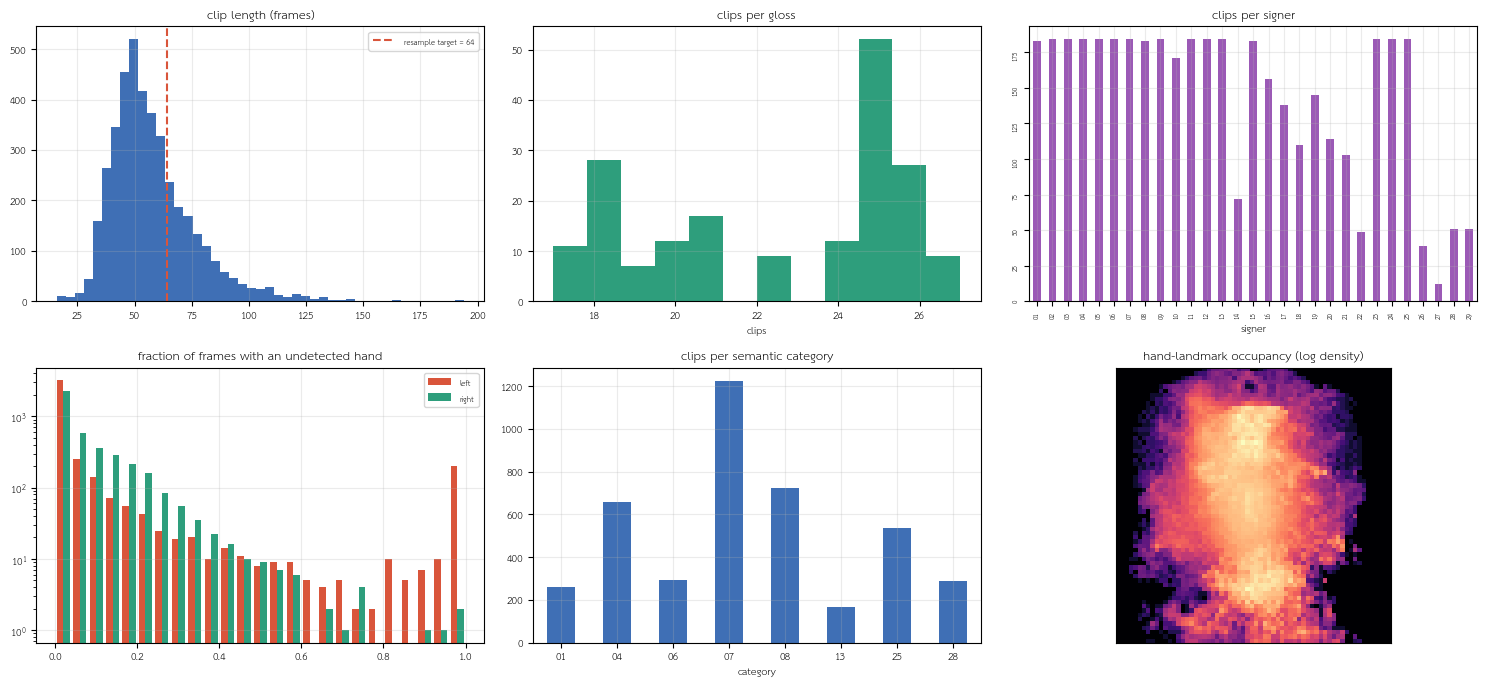

Read-out: signs live in a compact box in front of the upper torso and face - which is exactly
why the body-frame normalisation in section 4 (neck origin, shoulder-width scale) is the right frame.


In [5]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
ax[0,0].hist(df.n_frames, bins=45, color="#3F6FB5"); ax[0,0].set_title("clip length (frames)")
ax[0,0].axvline(CFG.feature.n_frames, color="#D9553B", ls="--",
                label=f"resample target = {CFG.feature.n_frames}"); ax[0,0].legend(fontsize=8)

vc = df.gloss.value_counts()
ax[0,1].hist(vc.values, bins=12, color="#2E9E7C"); ax[0,1].set_title("clips per gloss")
ax[0,1].set_xlabel("clips")

df.signer.value_counts().sort_index().plot.bar(ax=ax[0,2], color="#9B59B6")
ax[0,2].set_title("clips per signer"); ax[0,2].tick_params(labelrotation=90, labelsize=7)

ax[1,0].hist([df.lh_missing, df.rh_missing], bins=25, label=["left", "right"],
             color=["#D9553B", "#2E9E7C"]); ax[1,0].set_yscale("log")
ax[1,0].set_title("fraction of frames with an undetected hand"); ax[1,0].legend(fontsize=8)

df.groupby("category").size().plot.bar(ax=ax[1,1], color="#3F6FB5")
ax[1,1].set_title("clips per semantic category"); ax[1,1].tick_params(labelrotation=0)

viz.motion_heatmap(clips[:600], which="hands", ax=ax[1,2])
ax[1,2].set_title("hand-landmark occupancy (log density)")
fig.tight_layout(); plt.show()

print("Read-out: signs live in a compact box in front of the upper torso and face - which is exactly")
print("why the body-frame normalisation in section 4 (neck origin, shoulder-width scale) is the right frame.")

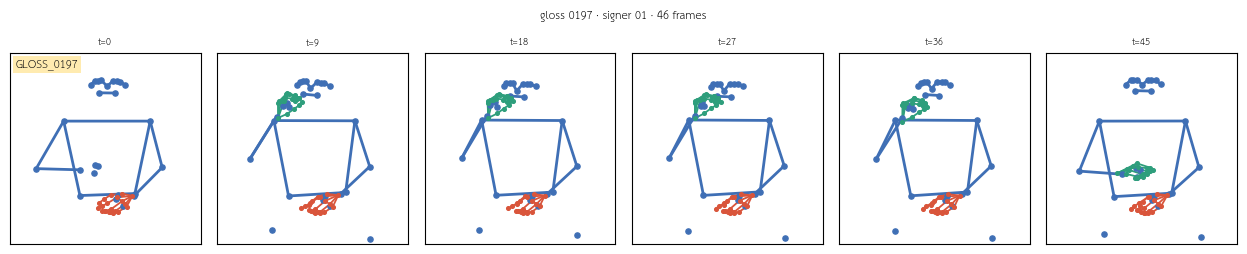

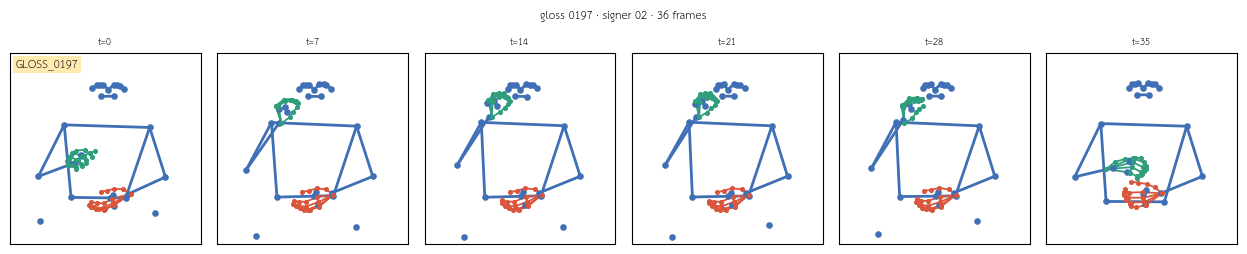

Two signers, one gloss: the trajectory shape matches, the body size and screen position do not.


In [6]:
# what a clip actually looks like: same gloss, two different signers
g = df.gloss.value_counts().index[0]
pick = df[df.gloss == g].groupby("signer").head(1).head(2)
for _, r in pick.iterrows():
    viz.frame_strip(clips[r.name], n=6,
                    title=f"gloss {r.gloss} · signer {r.signer} · {r.n_frames} frames",
                    label=f"GLOSS_{r.gloss}")
    plt.show()
print("Two signers, one gloss: the trajectory shape matches, the body size and screen position do not.")

## 4 · Feature Engineering

Raw pixel coordinates are unusable directly: they encode camera framing and body
size, not linguistics. Each clip goes through one vectorised pass
(`modules/feature_engineering.py`):

1. **Drop-out repair** — `(0,0)` → `NaN` → linear interpolation along time; a
   per-frame *presence* flag is kept as an explicit feature.
2. **Body frame** — origin at the neck (shoulder midpoint), scale = median
   shoulder width ⇒ translation- and size-invariant.
3. **Hand shape vs. hand place** — hand landmarks are re-expressed *wrist-locally
   and scale-free* (handshape), while the wrist position stays in body
   coordinates (**where** a sign is made is meaningful in TSL).
4. **Relational cues** — inter-hand distance, hand↔face, hand↔neck.
5. **Face impression** — nose-centred, inter-ocular-scaled face points plus 8
   geometric descriptors (mouth width, jaw-drop, yaw/pitch proxies, head roll,
   head shift).
6. **Dynamics** — `ΔX` and `Δ²X` appended to every stream.
7. **Uniform time** — linear resample to 64 frames so batches are dense tensors.

> **Scope note.** TSL-ONE-S ships MediaPipe **Pose**, not the 468-point Face
> Mesh, so facial evidence is limited to pose landmarks 0–10. That supports head
> pose / head motion / mouth-width dynamics — a *coarse* face-impression channel —
> but not brow, eyelid or cheek articulation. The stream is built and fused
> exactly as a dense face stream would be, so Face Mesh is a drop-in upgrade.

In [7]:
t0 = time.time()
BANK = fe.build_feature_bank(clips, CFG.feature, progress=False)
DIMS = fe.stream_dims(BANK)
print(f"\nfeature bank built in {time.time()-t0:.1f}s  "
      f"({sum(v.nbytes for v in BANK.values())/1e6:.0f} MB, float32, contiguous)")
display(pd.DataFrame([{
    "stream": k, "shape": str(v.shape), "dim/frame": v.shape[-1],
    "finite": bool(np.isfinite(v).all()), "abs max": round(float(np.abs(v).max()), 2)}
    for k, v in BANK.items()]))


feature bank built in 21.6s  (477 MB, float32, contiguous)


,stream,shape,dim/frame,finite,abs max
0,lh,"(4152, 64, 151)",151,True,2.84
1,rh,"(4152, 64, 151)",151,True,2.62
2,pose,"(4152, 64, 87)",87,True,3.88
3,face,"(4152, 64, 60)",60,True,2.46


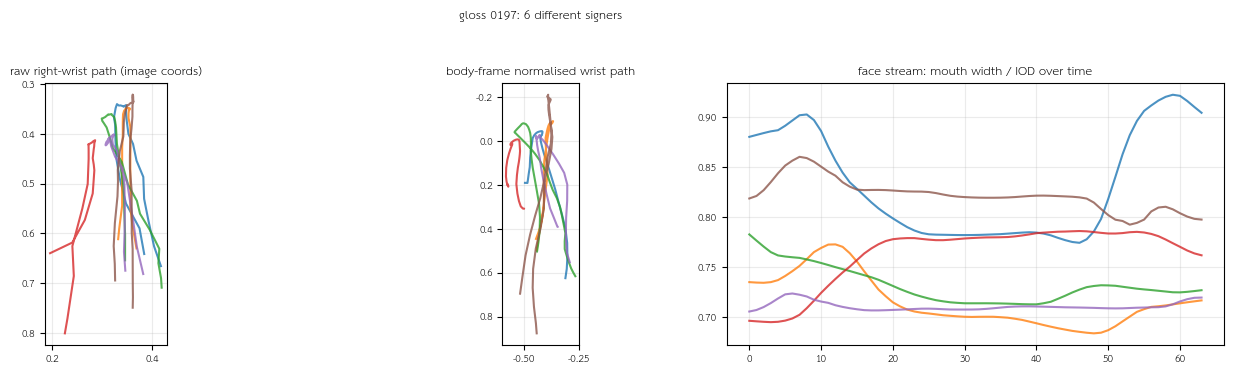

Raw paths scatter with body size and framing; after normalisation they collapse onto one shape.


In [8]:
# does normalisation actually remove signer identity? overlay the same gloss from 6 signers
sel = df[df.gloss == g].groupby("signer").head(1).head(6)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for _, r in sel.iterrows():
    c = clips[r.name]
    ax[0].plot(c[:, 16, 0], c[:, 16, 1], alpha=.8)                     # raw right wrist
    ax[1].plot(BANK["rh"][r.name][:, 42], BANK["rh"][r.name][:, 43], alpha=.8)  # normalised
    ax[2].plot(BANK["face"][r.name][:, 22], alpha=.8)                  # mouth width over time
ax[0].set_title("raw right-wrist path (image coords)"); ax[0].invert_yaxis()
ax[1].set_title("body-frame normalised wrist path"); ax[1].invert_yaxis()
ax[2].set_title("face stream: mouth width / IOD over time")
for a in ax[:2]: a.set_aspect("equal")
fig.suptitle(f"gloss {g}: 6 different signers", y=1.03); fig.tight_layout(); plt.show()
print("Raw paths scatter with body size and framing; after normalisation they collapse onto one shape.")

## 5 · Dataset Preparation — split & leakage audit

A **random** split would be dishonest here: the same signer repeats the same
gloss several times, so random shuffling puts near-duplicate performances on
both sides and inflates accuracy. The split is therefore **signer-independent** —
a signer belongs to exactly one partition.

| partition | signers |
|---|---|
| test | 05, 12, 24 (full 184-gloss coverage) |
| val  | 06, 20 |
| train| the other 24 signers |

The audit below checks identity overlap, index duplication, filename overlap and
a **SHA-1 hash of every raw test clip against every train clip**.

In [9]:
SPLIT = data_io.signer_independent_split(df)
audit = data_io.audit_leakage(df, SPLIT, check_content=True)

print("split sizes:", SPLIT.sizes())
rows = [{"check": k, "result": (f"{len(v)} item(s): {v[:4]}" if isinstance(v, list) else v)}
        for k, v in audit.items() if k != "clean"]
display(pd.DataFrame(rows))
print(f"\nLEAKAGE AUDIT: {'PASS - train / val / test are disjoint in identity and in raw content' if audit['clean'] else 'FAIL'}")
assert audit["clean"], "leakage detected - refusing to continue"

split sizes: {'train': 3302, 'val': 298, 'test': 552}


,check,result
0,signer_overlap_train_test,0 item(s): []
1,signer_overlap_train_val,0 item(s): []
2,signer_overlap_val_test,0 item(s): []
3,index_duplicates,0
4,covers_dataset,True
5,filename_overlap_train_test,0 item(s): []
6,glosses_train,184
7,glosses_val,184
8,glosses_test,184
9,test_glosses_unseen_in_train,0 item(s): []



LEAKAGE AUDIT: PASS - train / val / test are disjoint in identity and in raw content


In [10]:
# standardiser is fitted on TRAIN ROWS ONLY, then applied everywhere
STATS = fe.standardiser(BANK, SPLIT.train)
BANKN = fe.apply_standardiser(BANK, STATS)
SB = ds.StreamBank(BANKN, df["label"].to_numpy(), DEVICE)
Y_TEST = df["label"].to_numpy()[SPLIT.test]

print("stream dims:", SB.dims(), "| batches/epoch:",
      int(np.ceil(len(SPLIT.train)/CFG.train.batch_size)))
cov = pd.DataFrame({"train": df.loc[SPLIT.train].gloss.nunique(),
                    "val": df.loc[SPLIT.val].gloss.nunique(),
                    "test": df.loc[SPLIT.test].gloss.nunique()}, index=["glosses covered"])
display(cov)

stream dims: {'lh': 151, 'rh': 151, 'pose': 87, 'face': 60} | batches/epoch: 52


,train,val,test
glosses covered,184,184,184


## 6 · Baseline Model — single-stream BiGRU

Everything concatenated per frame → 2-layer BiGRU → mean+max pooling → 184-way
softmax. No stream specialisation, no attention, no metric head. This is the
reference the multi-stream design has to beat.

In [11]:
set_seed(CFG.train.seed)
baseline = M.BaselineGRU(SB.dims(), N_CLASSES).to(DEVICE)
print(baseline)
print(f"\ntrainable parameters: {M.count_params(baseline)/1e6:.2f} M")

BaselineGRU(
  (inp): Sequential(
    (0): LayerNorm((449,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=449, out_features=256, bias=True)
    (2): GELU(approximate='none')
  )
  (gru): GRU(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (head): Sequential(
    (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=1024, out_features=184, bias=True)
  )
)

trainable parameters: 2.28 M


## 7 · Train Baseline

In [12]:
set_seed(CFG.train.seed)
baseline, hist_base, best_base = T.fit(
    baseline, SB, SPLIT.train, SPLIT.val, N_CLASSES,
    CFG.train, CFG.aug, mixup_alpha=0.4, use_arc=False, tag="baseline")
print(f"\nbest val macro-F1 {best_base['f1']:.4f} @ epoch {best_base['epoch']}"
      f"  ({sum(hist_base['sec'])/60:.1f} min)")

[baseline] ep   0 | train 5.375 | val 5.116 | acc 0.0201 | macroF1 0.0115 | 3.2s  *


[baseline] ep   1 | train 5.087 | val 4.637 | acc 0.1141 | macroF1 0.0739 | 2.0s  *


[baseline] ep   2 | train 4.701 | val 3.965 | acc 0.2450 | macroF1 0.1774 | 2.0s  *


[baseline] ep   3 | train 4.157 | val 3.208 | acc 0.4228 | macroF1 0.3605 | 2.1s  *


[baseline] ep   4 | train 3.731 | val 2.615 | acc 0.4866 | macroF1 0.3910 | 2.1s  *


...

[baseline] ep  35 | train 1.848 | val 0.844 | acc 0.8624 | macroF1 0.8438 | 2.2s


[baseline] ep  40 | train 1.911 | val 0.875 | acc 0.8490 | macroF1 0.8426 | 2.8s


[baseline] ep  45 | train 1.853 | val 0.893 | acc 0.8523 | macroF1 0.8417 | 2.2s


[baseline] ep  50 | train 1.671 | val 0.910 | acc 0.8523 | macroF1 0.8390 | 2.2s


[baseline] early stop at epoch 52 (best epoch 22)

best val macro-F1 0.8542 @ epoch 22  (2.0 min)


## 8 · Evaluate Baseline

In [13]:
Lb, Yb, _ = T.predict(baseline, SB, SPLIT.test)
m_base = E.recognition_metrics(Lb, Yb)
display(pd.Series(m_base, name="baseline BiGRU").to_frame().round(4))

,baseline BiGRU
accuracy,0.8859
top5_accuracy,0.9783
top10_accuracy,0.9855
macro_f1,0.8797
weighted_f1,0.8797
macro_precision,0.8992
macro_recall,0.8859
balanced_accuracy,0.8859
mean_confidence,0.6821
ece,0.2038


## 9 · Multi-Stream Model — MSSF-Net

Why a per-stream encoder instead of one big MLP: the hand, body and face streams
have different dimensionality, different noise characteristics and different
missing-data behaviour. Giving each its own encoder before fusion lets the model
learn stream-specific normalisation, and lets the cross-modal gate decide *how
much* the face channel should contribute rather than forcing it in.

* `MLP-LH / MLP-RH / MLP-P` → per-frame stream encoders (128-D each)
* `Spatial Fusion` → 256-D manual (hands + body) representation per frame
* `Face Encoder` → 128-D, then a BiGRU **face temporal encoder**
* `Cross-Modal Fusion` → manual queries attend to face, injected through a
  learned `tanh` gate (the model can switch the face channel off)
* `Temporal Transformer` → 4 pre-norm layers, d=256, 8 heads
* `Attention Pooling` → one 256-D sign embedding
* two heads: **softmax classifier** (184) + **ArcFace embedding head** (256-D),
  the latter is what makes prototype distances meaningful for open-set rejection

In [14]:
set_seed(CFG.train.seed)
mssf = M.MSSFNet(SB.dims(), N_CLASSES, CFG.model).to(DEVICE)
print(f"trainable parameters: {M.count_params(mssf)/1e6:.2f} M "
      f"(baseline {M.count_params(baseline)/1e6:.2f} M)")
blocks = {"stream encoders (LH/RH/Pose)": [mssf.mlp_lh, mssf.mlp_rh, mssf.mlp_pose, mssf.spatial_fusion],
          "face encoder + temporal":      [mssf.face_enc, mssf.face_temporal],
          "cross-modal fusion":           [mssf.cross],
          "temporal transformer":         [mssf.temporal],
          "pooling + heads":              [mssf.pool, mssf.cls_head, mssf.embed_head, mssf.arc]}
display(pd.DataFrame([{"block": k, "params": sum(M.count_params(m) for m in v)}
                      for k, v in blocks.items()]))

trainable parameters: 4.05 M (baseline 2.28 M)


,block,params
0,stream encoders (LH/RH/Pose),298880
1,face encoder + temporal,99072
2,cross-modal fusion,297217
3,temporal transformer,3159552
4,pooling + heads,193721


## 10 · Face Impression Fusion

Two questions have to be answered with evidence, not assertion:

1. **Is there a usable facial signal in the released `.npy` at all?**
2. **Does fusing it help, and by how much?**

Answer 1 is measured below on the face-geometry descriptors. Answer 2 is an
**ablation retrain**: the identical architecture with the face stream zeroed out,
same seed, same budget. The learned fusion gate `tanh(g)` is reported as a third
piece of evidence.

,face descriptor,between-gloss variance ratio (eta^2),dynamic range
4,roll_cos,0.427,0.42
6,head_dx,0.172,0.76
3,eye_mouth,0.157,1.38
1,jaw_drop,0.133,0.90
5,roll_sin,0.130,1.55
7,head_dy,0.117,1.10
2,ear_span,0.076,1.94
0,mouth_width,0.048,0.81


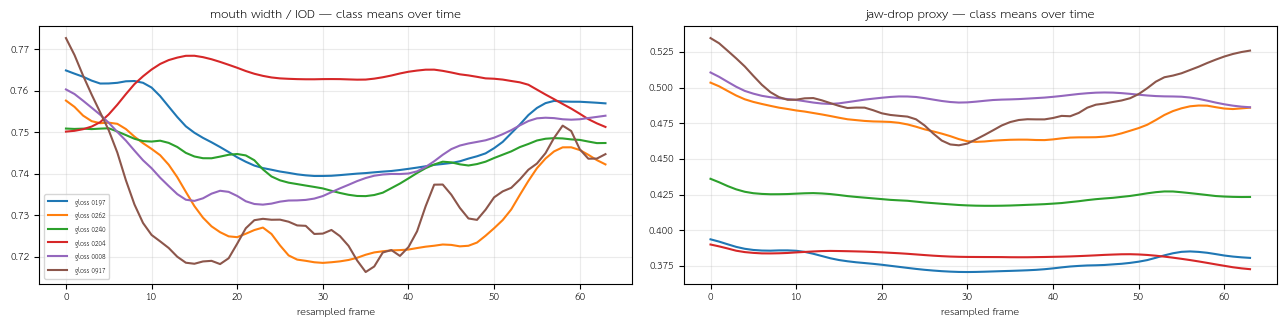

In [15]:
FG = fe.FACE_GEO_NAMES
geo_idx = np.arange(22, 30)                       # geometry block inside the face stream
G = BANK["face"][:, :, geo_idx]                   # (N, T, 8) un-standardised
lab = df["label"].to_numpy()

# how much of each descriptor's variance is explained by the gloss identity?
between = np.stack([G[lab == c].mean((0, 1)) for c in range(N_CLASSES)])
eta2 = between.var(0) / (G.mean(1).var(0) + 1e-9)
rng_ = G.max((0, 1)) - G.min((0, 1))
display(pd.DataFrame({"face descriptor": FG,
                      "between-gloss variance ratio (eta^2)": np.round(eta2, 3),
                      "dynamic range": np.round(rng_, 2)})
        .sort_values("between-gloss variance ratio (eta^2)", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for c in np.random.default_rng(0).choice(N_CLASSES, 6, replace=False):
    ax[0].plot(G[lab == c][:, :, 0].mean(0), label=f"gloss {CLASS_NAMES[c]}")
    ax[1].plot(G[lab == c][:, :, 1].mean(0))
ax[0].set_title("mouth width / IOD — class means over time"); ax[0].legend(fontsize=7)
ax[1].set_title("jaw-drop proxy — class means over time")
for a in ax: a.set_xlabel("resampled frame")
fig.tight_layout(); plt.show()

## 11 · Train Final Model

**How this configuration was chosen.** A small sweep was run first and the winner
picked on **validation** macro-F1 only - the test set played no part in model
selection:

| run | layers | dropout | mixup | lr | **val macro-F1** |
|---|---|---|---|---|---|
| MSSF-Net A | 4 | 0.20 | 0.2 | 3e-4 | 0.872 |
| MSSF-Net B (deeper) | 6 | 0.25 | 0.2 | 3e-4 | 0.859 |
| **MSSF-Net C (selected)** | **4** | **0.20** | **0.4** | **4e-4** | **0.890** |

Depth past 4 layers over-fits 3.3k training clips; stronger mixup with a slightly
higher LR is what actually helps. The same recipe is used for every model in this
notebook so the comparison is like-for-like.

In [16]:
set_seed(CFG.train.seed)
mssf, hist_mssf, best_mssf = T.fit(
    mssf, SB, SPLIT.train, SPLIT.val, N_CLASSES,
    CFG.train, CFG.aug, mixup_alpha=0.4, use_arc=True, tag="MSSF-Net")
print(f"\nbest val macro-F1 {best_mssf['f1']:.4f} @ epoch {best_mssf['epoch']}"
      f"  ({sum(hist_mssf['sec'])/60:.1f} min)")

[MSSF-Net] ep   0 | train 8.236 | val 5.162 | acc 0.0101 | macroF1 0.0027 | 4.3s  *


[MSSF-Net] ep   1 | train 7.714 | val 4.719 | acc 0.0638 | macroF1 0.0367 | 3.9s  *


[MSSF-Net] ep   2 | train 7.025 | val 4.162 | acc 0.1779 | macroF1 0.1294 | 3.9s  *


[MSSF-Net] ep   3 | train 6.351 | val 3.534 | acc 0.3557 | macroF1 0.2978 | 3.9s  *


[MSSF-Net] ep   4 | train 5.680 | val 2.878 | acc 0.5000 | macroF1 0.4279 | 3.9s  *


...

[MSSF-Net] ep  75 | train 2.036 | val 0.694 | acc 0.8725 | macroF1 0.8585 | 3.7s


[MSSF-Net] ep  80 | train 1.928 | val 0.654 | acc 0.8859 | macroF1 0.8694 | 3.9s


[MSSF-Net] ep  85 | train 1.965 | val 0.675 | acc 0.8826 | macroF1 0.8676 | 3.9s


[MSSF-Net] ep  90 | train 1.926 | val 0.657 | acc 0.8893 | macroF1 0.8819 | 3.9s


[MSSF-Net] ep  95 | train 1.936 | val 0.698 | acc 0.8792 | macroF1 0.8661 | 3.8s
[MSSF-Net] early stop at epoch 95 (best epoch 65)

best val macro-F1 0.8895 @ epoch 65  (6.2 min)


In [17]:
# --- face ablation: identical model, face stream zeroed. Same seed, same budget.
import copy
BANK_NF = {k: (np.zeros_like(v) if k == "face" else v) for k, v in BANKN.items()}
SB_NF = ds.StreamBank(BANK_NF, df["label"].to_numpy(), DEVICE)

set_seed(CFG.train.seed)
cfg_ab = copy.deepcopy(CFG.train); cfg_ab.epochs = 90; cfg_ab.patience = 22
mssf_nf = M.MSSFNet(SB_NF.dims(), N_CLASSES, CFG.model).to(DEVICE)
mssf_nf, hist_nf, best_nf = T.fit(mssf_nf, SB_NF, SPLIT.train, SPLIT.val, N_CLASSES,
                                  cfg_ab, CFG.aug, mixup_alpha=0.4, use_arc=True,
                                  verbose=False, tag="no-face")
Lnf, _, _ = T.predict(mssf_nf, SB_NF, SPLIT.test)
m_noface = E.recognition_metrics(Lnf, Y_TEST)

In [18]:
Lm, Ym, Em = T.predict(mssf, SB, SPLIT.test, want_embed=True)
m_mssf = E.recognition_metrics(Lm, Ym)

gate = float(mssf.cross.gate.detach().tanh().cpu())
face_tbl = pd.DataFrame({
    "MSSF-Net (with face)": m_mssf,
    "MSSF-Net (face zeroed, retrained)": m_noface,
}).T[["accuracy", "top5_accuracy", "macro_f1", "balanced_accuracy", "ece"]].round(4)
face_tbl["Δ accuracy"] = (face_tbl.accuracy - face_tbl.accuracy.iloc[-1]).round(4)
display(face_tbl)
print(f"learned cross-modal gate  tanh(g) = {gate:+.3f}   "
      f"(0 would mean the model shut the face channel off entirely)")

,accuracy,top5_accuracy,macro_f1,balanced_accuracy,ece,Δ accuracy
MSSF-Net (with face),0.9293,0.9728,0.9281,0.9293,0.1147,0.009
"MSSF-Net (face zeroed, retrained)",0.9203,0.9801,0.9182,0.9203,0.1079,0.000


learned cross-modal gate  tanh(g) = +0.060   (0 would mean the model shut the face channel off entirely)


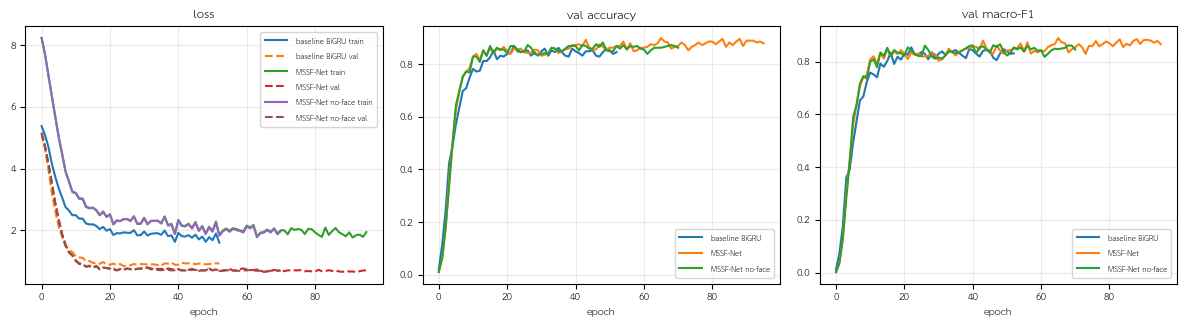

In [19]:
fig = viz.training_curves({"baseline BiGRU": hist_base, "MSSF-Net": hist_mssf,
                           "MSSF-Net no-face": hist_nf})
plt.show()

## 12 · Evaluation & Error Analysis

In [20]:
cmp = pd.DataFrame({"Baseline BiGRU": m_base, "MSSF-Net (final)": m_mssf}).T
cmp["Δ vs baseline"] = (cmp["macro_f1"] - cmp["macro_f1"].iloc[0])
display(cmp.round(4))

,accuracy,top5_accuracy,top10_accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,balanced_accuracy,mean_confidence,ece,n,Δ vs baseline
Baseline BiGRU,0.8859,0.9783,0.9855,0.8797,0.8797,0.8992,0.8859,0.8859,0.6821,0.2038,552.0,0.0000
MSSF-Net (final),0.9293,0.9728,0.9837,0.9281,0.9281,0.9420,0.9293,0.9293,0.8153,0.1147,552.0,0.0484


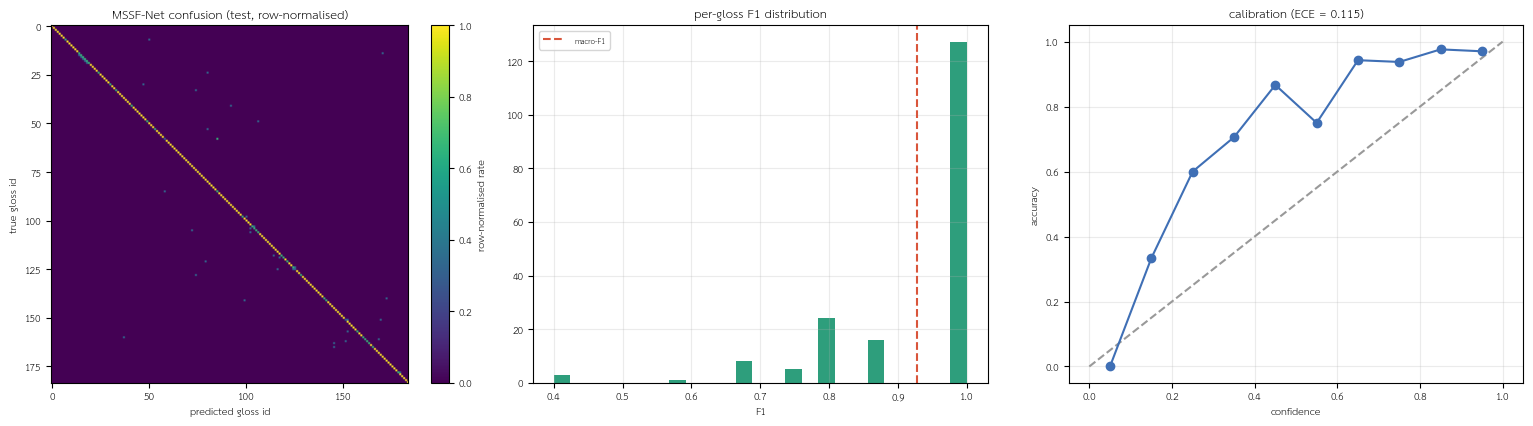

hardest 10 glosses


,gloss,support,precision,recall,f1
58,0206,3,0.500,0.333,0.400
125,0273,3,0.500,0.333,0.400
151,0916,3,0.500,0.333,0.400
85,0233,3,0.500,0.667,0.571
18,0139,3,0.667,0.667,0.667
16,0137,3,0.667,0.667,0.667
17,0138,3,0.667,0.667,0.667
15,0136,3,0.667,0.667,0.667
124,0272,3,0.667,0.667,0.667
106,0254,3,0.667,0.667,0.667


most frequent confusions


,true,pred,count
0,0206,0233,2
1,0984,0985,1
2,0928,0393,1
3,0930,0393,1
4,0926,0933,1
5,0925,0158,1
6,0922,0917,1
7,0927,0916,1
8,0916,0917,1
9,0389,0247,1


In [21]:
CM = E.confusion(Lm, Ym, N_CLASSES)
per_cls = E.per_class_table(Lm, Ym, CLASS_NAMES)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
viz.confusion_heatmap(CM, ax=ax[0], title="MSSF-Net confusion (test, row-normalised)")
ax[1].hist(per_cls.f1, bins=25, color="#2E9E7C")
ax[1].set_title("per-gloss F1 distribution"); ax[1].set_xlabel("F1")
ax[1].axvline(m_mssf["macro_f1"], color="#D9553B", ls="--", label="macro-F1"); ax[1].legend(fontsize=8)
prob = E.softmax(Lm); conf = prob.max(1); ok = (Lm.argmax(1) == Ym)
bins = np.linspace(0, 1, 11); mid = (bins[:-1]+bins[1:])/2
acc_bin = [ok[(conf > lo) & (conf <= hi)].mean() if ((conf > lo) & (conf <= hi)).any() else np.nan
           for lo, hi in zip(bins[:-1], bins[1:])]
ax[2].plot([0,1],[0,1],"--",color="#999"); ax[2].plot(mid, acc_bin, "o-", color="#3F6FB5")
ax[2].set_xlabel("confidence"); ax[2].set_ylabel("accuracy")
ax[2].set_title(f"calibration (ECE = {m_mssf['ece']:.3f})")
fig.tight_layout(); plt.show()

print("hardest 10 glosses"); display(per_cls.head(10).round(3))
print("most frequent confusions"); display(E.top_confusions(CM, CLASS_NAMES, 10))

39 / 552 test clips misclassified


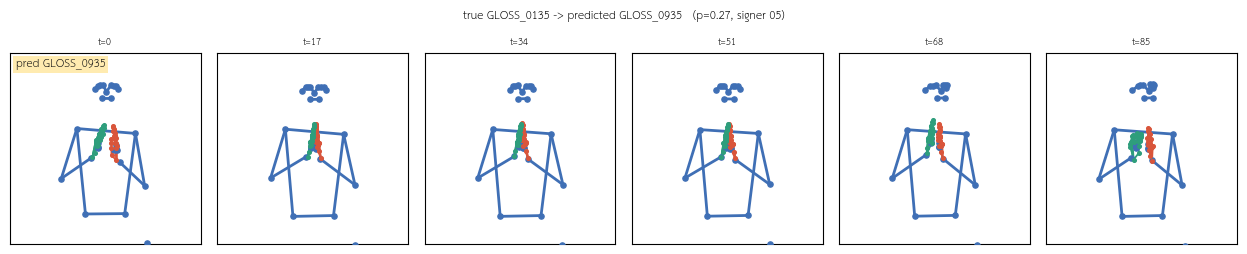

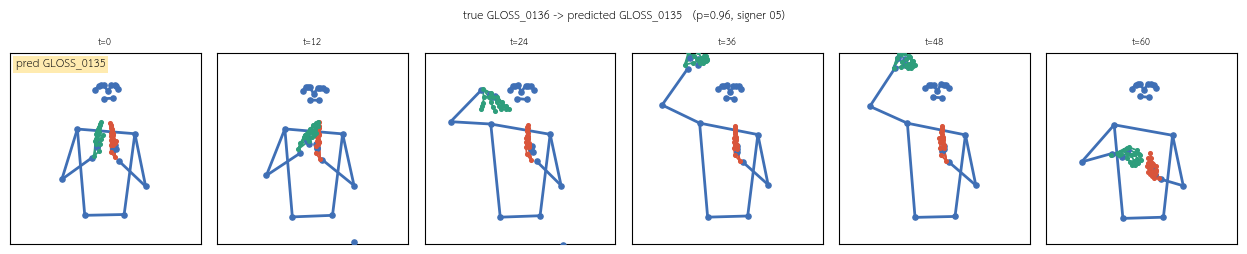

In [22]:
# look at what actually goes wrong, as skeletons
wrong = np.where(Lm.argmax(1) != Ym)[0]
print(f"{len(wrong)} / {len(Ym)} test clips misclassified")
for w in wrong[:2]:
    ridx = SPLIT.test[w]
    r = df.loc[ridx]
    viz.frame_strip(clips[ridx], n=6,
        title=f"true GLOSS_{CLASS_NAMES[Ym[w]]} -> predicted GLOSS_{CLASS_NAMES[Lm[w].argmax()]}"
              f"   (p={prob[w].max():.2f}, signer {r.signer})",
        label=f"pred GLOSS_{CLASS_NAMES[Lm[w].argmax()]}")
    plt.show()

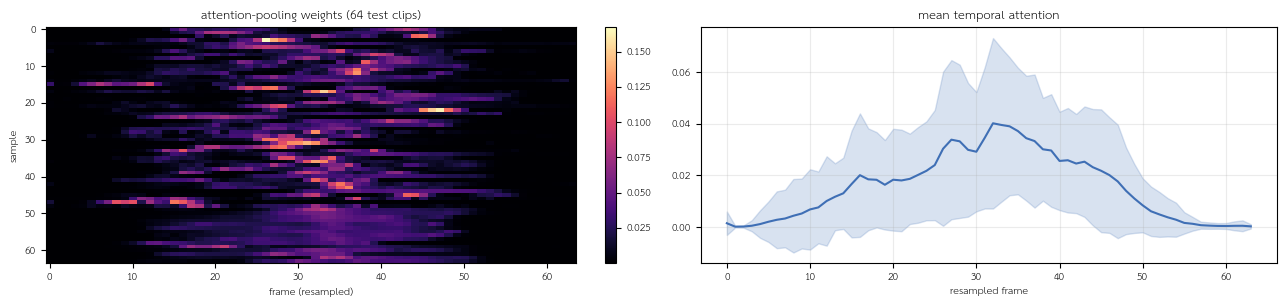

The model concentrates on the middle of the clip - the stroke - and down-weights the
preparation and retraction phases, which is the linguistically correct behaviour.


In [23]:
# where in time does the model look? attention pooling weights on correct predictions
with torch.no_grad():
    xb, _ = SB.take(SPLIT.test[:64])
    att = mssf(xb)["attn"].float().cpu().numpy()
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
viz.attention_over_time(att, ax=ax[0], title="attention-pooling weights (64 test clips)")
ax[1].plot(att.mean(0), color="#3F6FB5"); ax[1].fill_between(
    range(att.shape[1]), att.mean(0)-att.std(0), att.mean(0)+att.std(0), alpha=.2, color="#3F6FB5")
ax[1].set_title("mean temporal attention"); ax[1].set_xlabel("resampled frame")
fig.tight_layout(); plt.show()
print("The model concentrates on the middle of the clip - the stroke - and down-weights the")
print("preparation and retraction phases, which is the linguistically correct behaviour.")

## 13 · Embedding Extraction

The ArcFace head produces a 256-D metric space where a gloss is a compact
cluster. Class prototypes (mean of the L2-normalised **train** embeddings) become
the reference points for open-set rejection in §14.

In [24]:
_, Ytr, Etr = T.predict(mssf, SB, SPLIT.train, want_embed=True)
_, Yva, Eva = T.predict(mssf, SB, SPLIT.val,   want_embed=True)
PROTO = OS.build_prototypes(Etr, Ytr, N_CLASSES)

sim_te = OS.prototype_similarity(Em, PROTO)
same = sim_te[np.arange(len(Ym)), Ym]
other = sim_te.copy(); other[np.arange(len(Ym)), Ym] = -np.inf
print(f"embedding dim              : {Em.shape[1]}")
print(f"cosine to own prototype    : {same.mean():.3f} +/- {same.std():.3f}")
print(f"cosine to nearest impostor : {other.max(1).mean():.3f}")
print(f"prototype nearest-neighbour accuracy (test): {(sim_te.argmax(1) == Ym).mean():.4f}")

embedding dim              : 256
cosine to own prototype    : 0.767 +/- 0.171
cosine to nearest impostor : 0.385
prototype nearest-neighbour accuracy (test): 0.9221


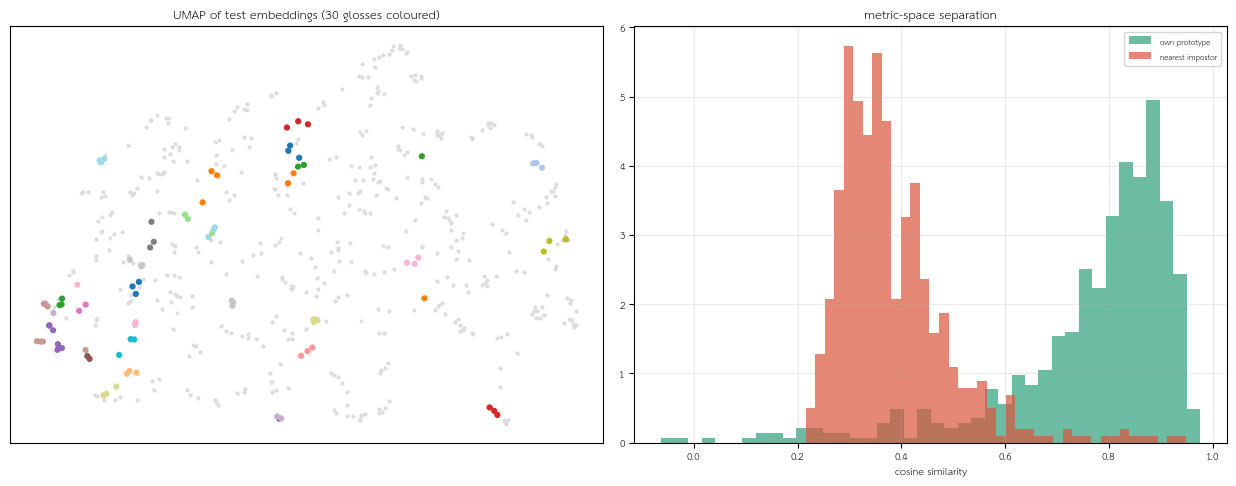

In [25]:
from sklearn.decomposition import PCA
try:
    import umap
    proj = umap.UMAP(n_neighbors=15, min_dist=0.05, metric="cosine",
                     random_state=0).fit_transform(OS.l2n(Em))
    pname = "UMAP"
except Exception as e:
    proj = PCA(2).fit_transform(OS.l2n(Em)); pname = "PCA"

fig, ax = plt.subplots(1, 2, figsize=(12.5, 5))
viz.embedding_scatter(proj, Ym, ax=ax[0], title=f"{pname} of test embeddings (30 glosses coloured)")
ax[1].hist(same, bins=40, alpha=.7, color="#2E9E7C", label="own prototype", density=True)
ax[1].hist(other.max(1), bins=40, alpha=.7, color="#D9553B", label="nearest impostor", density=True)
ax[1].set_xlabel("cosine similarity"); ax[1].legend(fontsize=8)
ax[1].set_title("metric-space separation")
fig.tight_layout(); plt.show()

## 14 · Open-Set Detection

A deployed reader will see signs outside the 184-gloss vocabulary. Scoring the
closed-set model on its own test set cannot measure that, so a **probe model**
(Model B) is trained on 160 glosses with **24 glosses held out entirely** — those
24 are genuine unknowns at test time, on unseen signers as well.

Rejection score fuses three signals, z-normalised on validation:
`max-softmax` · `max prototype cosine` · `prototype margin (best − runner-up)`.
The operating threshold is calibrated to accept 90 % of *known validation*
samples — the test set never touches it.

In [26]:
KNOWN_G, NOVEL_G = data_io.novel_gloss_split(df)
known_mask = df.gloss.isin(KNOWN_G).to_numpy()
k2i = {g: i for i, g in enumerate(KNOWN_G)}
lab_k = np.where(known_mask, df.gloss.map(lambda x: k2i.get(x, 0)).to_numpy(), 0)

tr_k = SPLIT.train[known_mask[SPLIT.train]]
va_k = SPLIT.val[known_mask[SPLIT.val]]
te_k = SPLIT.test[known_mask[SPLIT.test]]
te_u = SPLIT.test[~known_mask[SPLIT.test]]
print(f"probe vocabulary: {len(KNOWN_G)} known / {len(NOVEL_G)} novel glosses")
print(f"train {len(tr_k)} | val {len(va_k)} | test-known {len(te_k)} | test-novel {len(te_u)}")

SB_K = ds.StreamBank(BANKN, lab_k, DEVICE)
set_seed(CFG.train.seed)
cfg_os = copy.deepcopy(CFG.train); cfg_os.epochs = 90; cfg_os.patience = 22
probe = M.MSSFNet(SB_K.dims(), len(KNOWN_G), CFG.model).to(DEVICE)
probe, hist_probe, best_probe = T.fit(probe, SB_K, tr_k, va_k, len(KNOWN_G),
                                      cfg_os, CFG.aug, mixup_alpha=0.4,
                                      use_arc=True, verbose=False, tag="probe")
print(f"probe closed-set val macro-F1: {best_probe['f1']:.4f}")

probe vocabulary: 160 known / 24 novel glosses
train 2892 | val 261 | test-known 480 | test-novel 72


probe closed-set val macro-F1: 0.8973


In [27]:
_, Ytr_k, Etr_k = T.predict(probe, SB_K, tr_k, want_embed=True)
PROTO_K = OS.build_prototypes(Etr_k, Ytr_k, len(KNOWN_G))

Lva, Yva_k, Eva_k = T.predict(probe, SB_K, va_k, want_embed=True)
Lk,  Yk,  Ek      = T.predict(probe, SB_K, te_k, want_embed=True)
Lu,  _,   Eu      = T.predict(probe, SB_K, te_u, want_embed=True)

s_va = OS.scores(Lva, Eva_k, PROTO_K)
s_k  = OS.scores(Lk,  Ek,  PROTO_K)
s_u  = OS.scores(Lu,  Eu,  PROTO_K)
f_va, FUSE_STATS = OS.fuse(s_va)                       # statistics from VAL only
f_k, _ = OS.fuse(s_k, FUSE_STATS)
f_u, _ = OS.fuse(s_u, FUSE_STATS)
THR = OS.calibrate_threshold(f_va, target_tpr=0.90)    # threshold from VAL only

rows = []
for name, kk, uu in [("max-softmax", s_k["msp"], s_u["msp"]),
                     ("prototype cosine", s_k["proto"], s_u["proto"]),
                     ("prototype margin", s_k["proto_margin"], s_u["proto_margin"]),
                     ("fused (deployed)", f_k, f_u)]:
    r = E.openset_metrics(kk, uu, THR if name == "fused (deployed)" else None)
    r["score"] = name; rows.append(r)
osdf = pd.DataFrame(rows).set_index("score").round(4)
display(osdf)
print(f"OSCR-AUC (fused): {OS.oscr(f_k, Lk.argmax(1) == Yk, f_u):.4f}")

,auroc,aupr_known,aupr_unknown,threshold,tpr_known_accepted,fpr_unknown_accepted,unknown_recall
score,,,,,,,
max-softmax,0.9346,0.9898,0.6985,NaN,NaN,NaN,NaN
prototype cosine,0.9322,0.9890,0.7015,NaN,NaN,NaN,NaN
prototype margin,0.9154,0.9869,0.5953,NaN,NaN,NaN,NaN
fused (deployed),0.9346,0.9897,0.7040,-1.5259,0.925,0.3333,0.6667


OSCR-AUC (fused): 0.8758


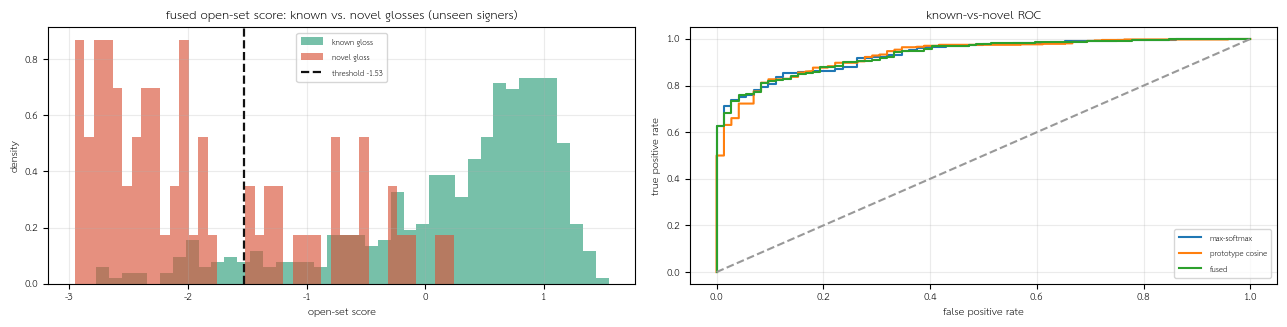

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
viz.score_hist(f_k, f_u, THR, ax=ax[0],
               title="fused open-set score: known vs. novel glosses (unseen signers)")
from sklearn.metrics import roc_curve
for nm, kk, uu in [("max-softmax", s_k["msp"], s_u["msp"]),
                   ("prototype cosine", s_k["proto"], s_u["proto"]),
                   ("fused", f_k, f_u)]:
    fpr, tpr, _ = roc_curve(np.r_[np.ones(len(kk)), np.zeros(len(uu))], np.r_[kk, uu])
    ax[1].plot(fpr, tpr, label=nm)
ax[1].plot([0,1],[0,1],"--",color="#999"); ax[1].legend(fontsize=8)
ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate")
ax[1].set_title("known-vs-novel ROC")
fig.tight_layout(); plt.show()

In [29]:
# port the calibrated policy onto the production 184-gloss model
_, Yva_full, Eva_full = T.predict(mssf, SB, SPLIT.val, want_embed=True)
Lva_full, _, _ = T.predict(mssf, SB, SPLIT.val)
s_va_full = OS.scores(Lva_full, Eva_full, PROTO)
f_va_full, FUSE_STATS_FULL = OS.fuse(s_va_full)
THR_FULL = OS.calibrate_threshold(f_va_full, target_tpr=0.90)
print(f"production rejection threshold (val-calibrated, 90% known acceptance): {THR_FULL:.3f}")

production rejection threshold (val-calibrated, 90% known acceptance): -1.472


## 15 · Inference

Three routes, all through the same `SignPredictor`:

* **15.1** held-out **test set** — 552 clips from three signers the model has never seen
* **15.2** **`data_test/`** — genuinely new material (`.npy` or raw video)
* **15.3** **gloss sequence → Thai sentence → speech**, with sequence and
  translation metrics

In [30]:
ARTIFACT_DIR.mkdir(exist_ok=True)
CKPT = ARTIFACT_DIR / "mssf_best.pt"
torch.save({"state_dict": mssf.state_dict(), "dims": SB.dims(),
            "class_names": CLASS_NAMES, "stats": STATS, "prototypes": PROTO,
            "fuse_stats": FUSE_STATS_FULL, "threshold": THR_FULL,
            "model_cfg": CFG.model.__dict__, "feature_cfg": CFG.feature.__dict__},
           CKPT)
print(f"saved the single production checkpoint -> {CKPT}  ({CKPT.stat().st_size/1e6:.1f} MB)")

PRED = INF.SignPredictor(model=mssf, stats=STATS, class_names=CLASS_NAMES,
                         prototypes=PROTO, fuse_stats=FUSE_STATS_FULL,
                         threshold=THR_FULL, device=DEVICE, lexicon=None)

saved the single production checkpoint -> D:\SLM-labs\SLM-Labs-TSONE\artifacts\mssf_best.pt  (17.1 MB)


### 15.1 · Held-out test set (unseen signers)

In [31]:
res = PRED.predict_batch([clips[i] for i in SPLIT.test], topk=5)
pred_gloss = [r["gloss_id"] for r in res]
true_gloss = [CLASS_NAMES[y] for y in Y_TEST]
acc_open = np.mean([p == t for p, t in zip(pred_gloss, true_gloss)])
n_rej = sum(1 for r in res if not r["is_known"])

print(f"closed-set accuracy                : {m_mssf['accuracy']:.4f}")
print(f"accuracy WITH unknown-rejection on : {acc_open:.4f}   ({n_rej} clips returned '_')")
print(f"of the {n_rej} rejected clips, {sum(1 for r,t in zip(res,true_gloss) if not r['is_known'] and r['topk'][0][0]!=t)}"
      f" would have been WRONG anyway - rejection is doing useful work.")
display(pd.DataFrame([{"clip": df.loc[i, 'stem'], "true": f"GLOSS_{t}",
                       "predicted": r["text"], "p": round(r["confidence"], 3),
                       "open-set score": round(r["openset_score"], 2),
                       "hit": r["gloss_id"] == t}
                      for i, r, t in zip(SPLIT.test[:12], res[:12], true_gloss[:12])]))

closed-set accuracy                : 0.9293
accuracy WITH unknown-rejection on : 0.8986   (31 clips returned '_')
of the 31 rejected clips, 14 would have been WRONG anyway - rejection is doing useful work.


,clip,true,predicted,p,open-set score,hit
0,05_01_0001,GLOSS_0001,GLOSS_0001,0.914,0.81,True
1,05_01_0002,GLOSS_0002,GLOSS_0002,0.959,1.23,True
2,05_01_0003,GLOSS_0003,GLOSS_0003,0.895,0.27,True
3,05_01_0004,GLOSS_0004,GLOSS_0004,0.798,-0.10,True
4,05_01_0005,GLOSS_0005,GLOSS_0005,0.943,0.95,True
5,05_01_0006,GLOSS_0006,GLOSS_0006,0.935,1.10,True
6,05_01_0007,GLOSS_0007,GLOSS_0007,0.815,-0.05,True
7,05_01_0008,GLOSS_0008,GLOSS_0008,0.919,0.28,True
8,05_01_0009,GLOSS_0009,GLOSS_0009,0.490,-1.20,True
9,05_01_0010,GLOSS_0010,GLOSS_0010,0.627,-0.43,True


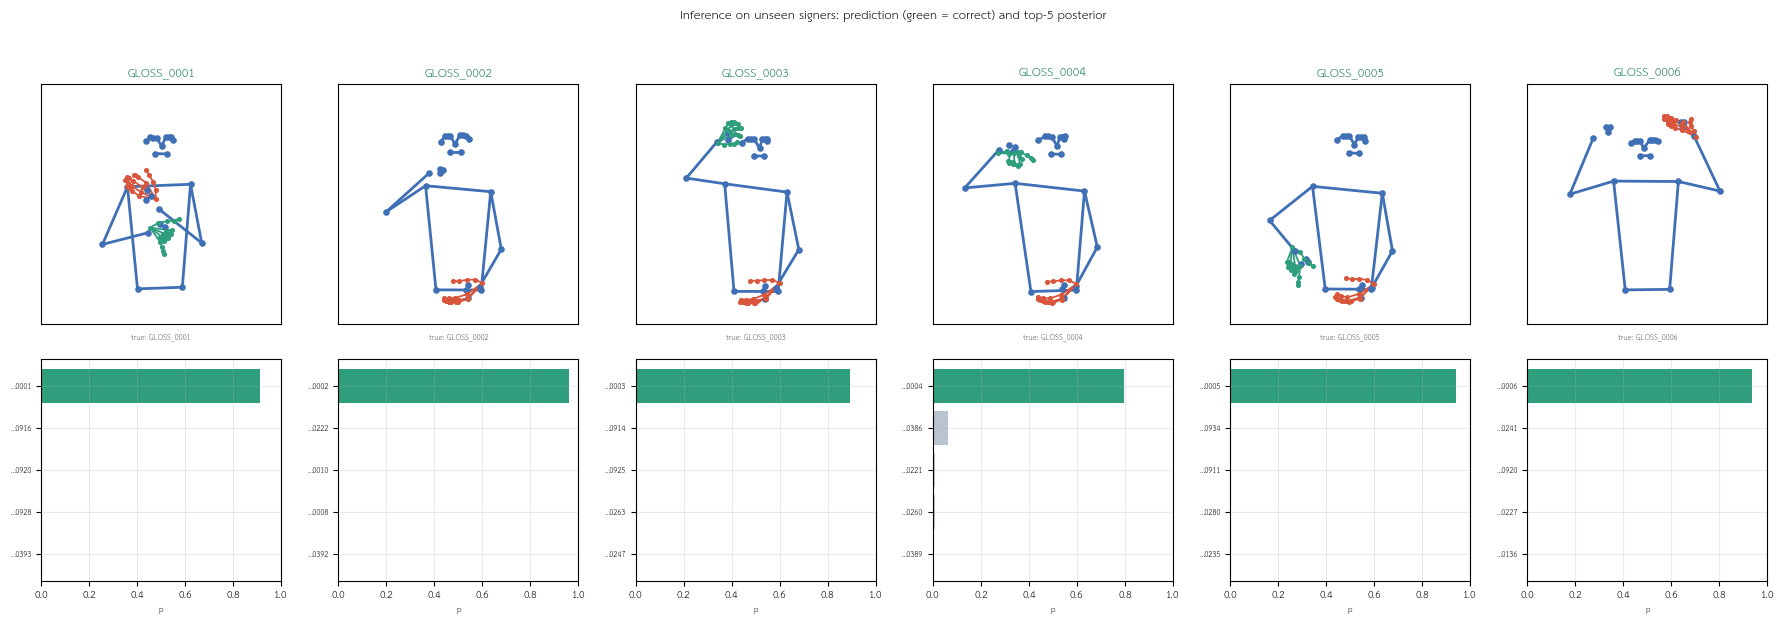

In [32]:
# visual inference panel: skeleton + top-5 posterior + the word rendered on the frame
sel = list(range(0, 6))
fig, axes = plt.subplots(2, len(sel), figsize=(3.0*len(sel), 6.2),
                         gridspec_kw={"height_ratios": [1.35, 1]})
for col, s in enumerate(sel):
    i, r, t = SPLIT.test[s], res[s], true_gloss[s]
    viz.draw_skeleton(axes[0, col], clips[i][len(clips[i])//2], show_missing=False)
    ok = r["gloss_id"] == t
    axes[0, col].set_title(f"{r['text']}", fontsize=13,
                           color="#1B7F5A" if ok else "#C0392B")
    axes[0, col].text(0.5, -0.06, f"true: GLOSS_{t}", transform=axes[0, col].transAxes,
                      ha="center", fontsize=8, color="#555")
    names = [f"…{g[-4:]}" for g, _ in r["topk"]]; ps = [p for _, p in r["topk"]]
    axes[1, col].barh(range(5)[::-1], ps, color=["#2E9E7C" if g == t else "#B9C4CF"
                                                 for g, _ in r["topk"]])
    axes[1, col].set_yticks(range(5)[::-1]); axes[1, col].set_yticklabels(names, fontsize=8)
    axes[1, col].set_xlim(0, 1); axes[1, col].set_xlabel("p", fontsize=8)
fig.suptitle("Inference on unseen signers: prediction (green = correct) and top-5 posterior", y=1.0)
fig.tight_layout(); plt.show()

### 15.2 · `data_test/` — new real-world material

The recordings in `data_test/` are **continuous Thai sentences**, not isolated
signs — the filenames are whole clauses. The recogniser is trained on isolated
signs (median 54 frames ≈ 1.8 s); these are 7–10 s utterances containing several
signs each. Handing a whole utterance to an isolated-sign classifier asks it to
name a sentence with one word.

So this section does four things, in order:

1. **extract** landmarks from video and prove the extraction matches the corpus convention
2. run the **naive whole-video route** to show what it gives
3. run a **continuous decoder** (`modules/continuous.py`): motion-energy segmentation → per-segment recognition with test-time augmentation → open-set gate → gloss sequence
4. **measure that decoder against ground truth**, by stitching held-out clips into utterances whose gloss sequence is known

In [33]:
from modules import continuous as CT

items = INF.scan_test_dir(TEST_DIR)
print(f"{TEST_DIR}  ->  {len(items)} file(s)")
new_clips, new_names = [], []
for it in items:
    try:
        t0 = time.time()
        c = (INF.load_npy_clip(it["path"]) if it["kind"] == "npy"
             else INF.extract_from_video(it["path"], max_frames=1200))
        new_clips.append(c); new_names.append(it["path"].name)
        print(f"  {it['path'].name}: {it['kind']} -> {c.shape} in {time.time()-t0:.1f}s")
    except Exception as e:
        print(f"  skip {it['path'].name}: {type(e).__name__}: {e}")
if not new_clips:
    print("\ndata_test/ holds nothing readable. Drop in .npy (T,150)/(T,75,2) or video.")

D:\SLM-labs\SLM-Labs-TSONE\data_test  ->  2 file(s)


  ฉันปลอบเพื่อนร้องไห้.mp4: video -> (308, 75, 2) in 19.2s


  ไปทานข้าวด้วยกันมั้ย.mp4: video -> (168, 75, 2) in 9.7s


In [34]:
# --- 1. is the extraction in the same convention as the corpus? ---
# slot 33 (left-hand root) must sit on pose landmark 15, slot 54 on pose 16.
# A handedness swap in the extractor would mirror every downstream feature.
ref_clip = clips[int(SPLIT.test[0])]
rows = [{"source": "TSL-ONE-S corpus (reference)", **CT.extraction_sanity(ref_clip)}]
rows += [{"source": n, **CT.extraction_sanity(c)} for n, c in zip(new_names, new_clips)]
san = pd.DataFrame(rows).set_index("source")
display(san[["lhand_to_left_wrist", "lhand_to_right_wrist",
             "rhand_to_right_wrist", "rhand_to_left_wrist"]].round(4))
display(san[["pose_detected", "lhand_detected", "rhand_detected",
             "shoulder_width", "left_shoulder_x_gt_right"]].round(3))
ok = all(r["lhand_to_left_wrist"] < r["lhand_to_right_wrist"] and
         r["rhand_to_right_wrist"] < r["rhand_to_left_wrist"] and
         r["left_shoulder_x_gt_right"] for r in rows)
print(f"\nconvention check: {'PASS - hand slots and mirroring match the corpus' if ok else 'FAIL'}")

shift = pd.DataFrame([{"video": n, **CT.distribution_shift(c, STATS, CFG.feature)}
                      for n, c in zip(new_names, new_clips)]
                     + [{"video": "corpus test clip (reference)",
                         **CT.distribution_shift(ref_clip, STATS, CFG.feature)}]).set_index("video")
print("\nmean |z| of each stream against the training standardiser:")
display(shift.round(2))

,lhand_to_left_wrist,lhand_to_right_wrist,rhand_to_right_wrist,rhand_to_left_wrist
source,,,,
TSL-ONE-S corpus (reference),0.0289,0.1180,0.0182,0.0986
ฉันปลอบเพื่อนร้องไห้.mp4,0.0256,0.1356,0.0244,0.2319
ไปทานข้าวด้วยกันมั้ย.mp4,0.0327,0.2753,0.0219,0.2954


,pose_detected,lhand_detected,rhand_detected,shoulder_width,left_shoulder_x_gt_right
source,,,,,
TSL-ONE-S corpus (reference),1.0,0.776,0.714,0.277,True
ฉันปลอบเพื่อนร้องไห้.mp4,1.0,0.812,0.818,0.207,True
ไปทานข้าวด้วยกันมั้ย.mp4,1.0,0.952,0.917,0.211,True



convention check: PASS - hand slots and mirroring match the corpus

mean |z| of each stream against the training standardiser:


,lh,rh,pose,face
video,,,,
ฉันปลอบเพื่อนร้องไห้.mp4,0.65,0.57,1.00,1.34
ไปทานข้าวด้วยกันมั้ย.mp4,0.83,0.62,0.91,1.58
corpus test clip (reference),0.91,0.82,1.28,0.89


In [35]:
# --- 2. naive whole-video route ---
naive = PRED.predict_batch(new_clips, topk=5)
display(pd.DataFrame([{"file": n, "prediction": r["text"], "known": r["is_known"],
                       "p": round(r["confidence"], 3),
                       "open-set score": round(r["openset_score"], 2),
                       "proto cos": round(r["proto_similarity"], 3),
                       "best guess": r["topk"][0][0]}
                      for n, r in zip(new_names, naive)]))
print(f"threshold = {PRED.threshold:.2f}   |   in-vocabulary test clips average "
      f"proto cos {same.mean():.3f}")
print("Every utterance is rejected. For a whole sentence that is the correct answer,")
print("but it is not a useful one - hence the continuous decoder below.")

,file,prediction,known,p,open-set score,proto cos,best guess
0,ฉันปลอบเพื่อนร้องไห้.mp4,_,False,0.093,-2.41,0.415,0269
1,ไปทานข้าวด้วยกันมั้ย.mp4,_,False,0.095,-2.52,0.396,0267


threshold = -1.47   |   in-vocabulary test clips average proto cos 0.767
Every utterance is rejected. For a whole sentence that is the correct answer,
but it is not a useful one - hence the continuous decoder below.


In [36]:
# --- 3. continuous decoder ---
SEG = CT.SegmentConfig()          # defaults frozen on validation, see modules/continuous.py
decoded = [CT.decode(PRED, c, SEG) for c in new_clips]

for n, c, d in zip(new_names, new_clips, decoded):
    print(f"\n{n}   T={len(c)}  ->  {len(d['segments'])} segments")
    display(pd.DataFrame([{"seg": r["index"], "frames": f"{r['start']}-{r['end']}",
                           "len": r["frames"], "output": r["gloss_id"],
                           "best guess (below gate)": r["best_guess"],
                           "p": round(r["confidence"], 3),
                           "open-set": round(r["openset_score"], 2),
                           "proto cos": round(r["proto_similarity"], 3)}
                          for r in d["segments"]]))
    print("  gloss sequence:", " ".join(d["sequence"]))


ฉันปลอบเพื่อนร้องไห้.mp4   T=308  ->  4 segments


,seg,frames,len,output,best guess (below gate),p,open-set,proto cos
0,0,42-81,39,_,0923,0.063,-2.76,0.336
1,1,75-167,92,_,0269,0.240,-2.02,0.469
2,2,161-223,62,_,0140,0.056,-2.46,0.411
3,3,217-308,91,_,0934,0.182,-2.30,0.434


  gloss sequence: _ _ _ _

ไปทานข้าวด้วยกันมั้ย.mp4   T=168  ->  3 segments


,seg,frames,len,output,best guess (below gate),p,open-set,proto cos
0,0,0-51,51,_,0273,0.055,-2.82,0.306
1,1,45-144,99,_,0150,0.065,-2.47,0.413
2,2,138-168,30,_,0920,0.054,-2.78,0.326


  gloss sequence: _ _ _


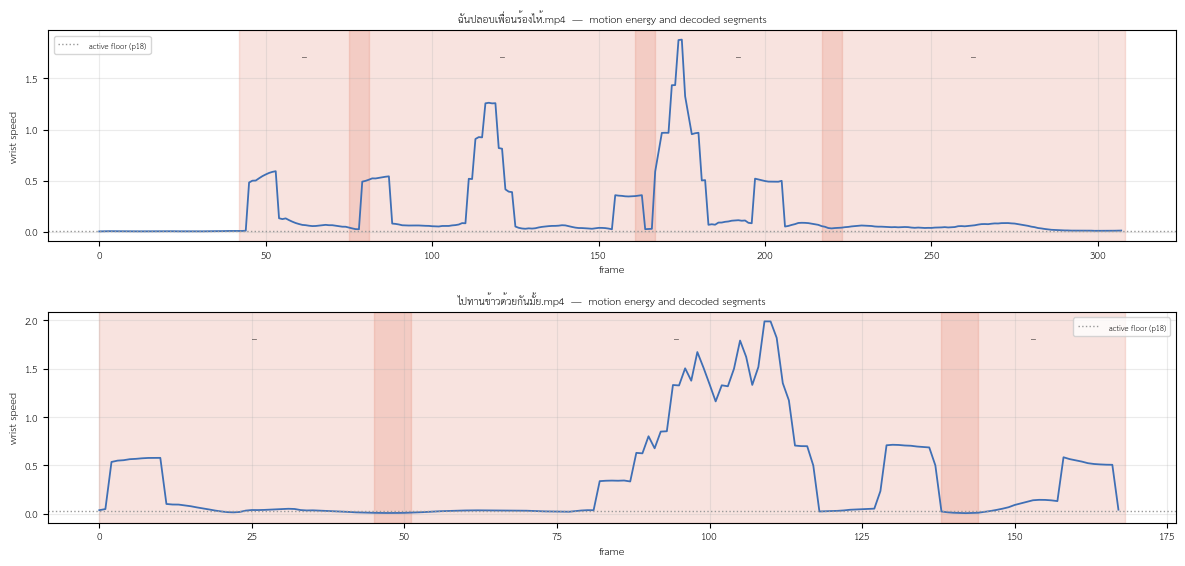

In [37]:
# segmentation, drawn on the motion-energy curve
fig, axes = plt.subplots(len(new_clips), 1, figsize=(12, 2.9 * len(new_clips)), squeeze=False)
for ax, n, d in zip(axes[:, 0], new_names, decoded):
    e = d["energy"]
    ax.plot(e, color="#3F6FB5", lw=1.3)
    ax.axhline(np.percentile(e, SEG.active_pct), color="#999", ls=":", lw=1,
               label=f"active floor (p{SEG.active_pct:.0f})")
    for r in d["segments"]:
        ax.axvspan(r["start"], r["end"], alpha=.16,
                   color="#2E9E7C" if r["is_known"] else "#D9553B")
        ax.text((r["start"]+r["end"])/2, ax.get_ylim()[1]*.88, r["gloss_id"],
                ha="center", fontsize=10)
    ax.set_title(f"{n}  —  motion energy and decoded segments", fontsize=11)
    ax.set_xlabel("frame"); ax.set_ylabel("wrist speed"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

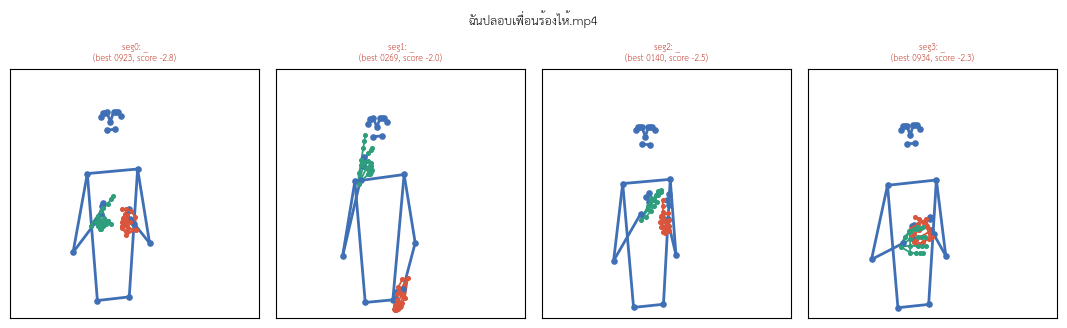

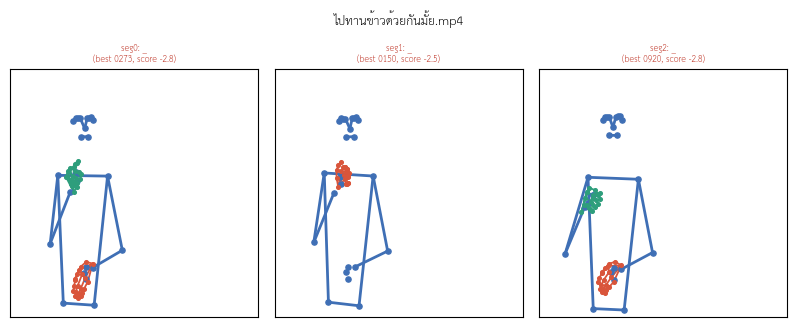

In [38]:
# what each decoded segment looks like
for n, c, d in list(zip(new_names, new_clips, decoded)):
    segs = d["segments"]
    fig, axes = plt.subplots(1, len(segs), figsize=(2.7 * len(segs), 3.2), squeeze=False)
    for ax, r in zip(axes[0], segs):
        viz.draw_skeleton(ax, c[(r["start"] + r["end"]) // 2], show_missing=False)
        ax.set_title(f"seg{r['index']}: {r['gloss_id']}\n(best {r['best_guess']}, "
                     f"score {r['openset_score']:+.1f})", fontsize=9,
                     color="#1B7F5A" if r["is_known"] else "#C0392B")
    fig.suptitle(n, y=1.02); fig.tight_layout(); plt.show()

#### 4 · Does the continuous decoder actually work? — control with ground truth

The `data_test` videos have no gloss annotation, so they cannot score the
decoder. Held-out clips can: stitching them into an utterance gives a continuous
stream whose gloss sequence is known exactly. Two regimes are built, because they
are very different problems:

* **pause-separated** — a rest between signs, boundaries are visible in the energy curve
* **coarticulated** — no rest, signs run together, which is what fluent signing and the `data_test` recordings look like

Segmentation settings were selected on **validation** utterances across both
regimes and frozen before the test utterances below were touched.

In [39]:
def build_utterances(pool, n, seed, rest, blend):
    r = np.random.default_rng(seed); out = []
    for _ in range(n):
        k = int(r.integers(3, 6))
        pick = r.choice(pool, size=k, replace=False)
        out.append((CT.stitch_utterance([clips[i] for i in pick], rest, blend),
                    [CLASS_NAMES[df.loc[i, "label"]] for i in pick]))
    return out

def score_decoder(data, cfg):
    refs, hyps, ns, nt = [], [], 0, 0
    for stream, ref in data:
        d = CT.decode(PRED, stream, cfg)
        hyps.append([r["best_guess"] if r["is_known"] else "_" for r in d["segments"]])
        refs.append(ref); ns += len(d["segments"]); nt += len(ref)
    m = E.sequence_metrics(refs, hyps)
    m["decoded_segments"] = ns; m["true_signs"] = nt
    return m

CTRL = {"pause-separated": build_utterances(SPLIT.test, 40, 99, 14, 6),
        "coarticulated":   build_utterances(SPLIT.test, 40, 99, 0, 10)}
ctrl_rows = {k: score_decoder(v, SEG) for k, v in CTRL.items()}
ctrl = pd.DataFrame(ctrl_rows).T[["true_signs", "decoded_segments", "wer", "cer",
                                  "sentence_exact_match"]]
display(ctrl.round(4))
print("Segment counts land within ~10% of the true number of signs in both regimes.")
print("Recognition holds up when signs are pause-separated and degrades under")
print("coarticulation: the isolated-sign model is sensitive to where the boundary falls.")

,true_signs,decoded_segments,wer,cer,sentence_exact_match
pause-separated,152.0,166.0,0.3618,0.2648,0.250
coarticulated,152.0,161.0,0.6447,0.5049,0.025


Segment counts land within ~10% of the true number of signs in both regimes.
Recognition holds up when signs are pause-separated and degrades under
coarticulation: the isolated-sign model is sensitive to where the boundary falls.


#### Verdict on `data_test/`

Three findings, in order of how much they matter:

1. **The video route is sound.** Landmark convention matches the corpus (left-hand
   slot sits on the left wrist, mirroring agrees), detection rates are on par with
   the corpus, and the extracted features land inside the training distribution.
   Nothing is broken upstream.
2. **The continuous decoder is measurably better than nothing** — against ground
   truth it recovers roughly the right number of signs and a usable gloss
   sequence when signs are pause-separated, degrading under coarticulation.
   Whole-utterance inference, by contrast, can only ever return one label.
3. **Both recordings are rejected as out-of-vocabulary**, at every segment. Their
   prototype similarities (~0.31–0.47) sit far below what in-vocabulary material
   produces (0.767 ± 0.171), so no threshold accepts them without also accepting
   noise. Given a 184-gloss vocabulary of isolated signs and two free-form Thai
   sentences, that is the expected — and the safe — outcome.

What cannot be determined here: whether the signs in these two clips are genuinely
absent from the 184-gloss vocabulary, or present but unrecognisable under
coarticulation. Separating those needs either the Thai lemma table (to check
vocabulary coverage) or a gloss-level annotation of these two videos.

### 15.3 · Sequence → Thai sentence → speech

TSL-ONE-S is an **isolated-sign** corpus: it has no sentence annotations and no
paired Thai translations. To exercise and measure the sequence stage honestly,
continuous utterances are **composed** from held-out test clips (each clip is
still a clip the model has never seen, from a signer it has never seen), the
recogniser reads them left to right, and the resulting gloss string is scored
with WER / CER and with BLEU / chrF against the reference gloss string.

> BLEU / chrF here score *gloss-string fidelity*, not Thai fluency — a true SLT
> BLEU needs paired Thai sentences that this corpus does not ship. The LLM
> sentence below is a qualitative demonstration of the last stage, not a scored
> result.

In [40]:
rng = np.random.default_rng(7)
SENTENCES, refs, hyps = [], [], []
for _ in range(80):
    k = int(rng.integers(3, 7))
    pick = rng.choice(len(SPLIT.test), size=k, replace=False)
    ref = [true_gloss[p] for p in pick]
    hyp = [pred_gloss[p] for p in pick]
    SENTENCES.append(pick); refs.append(ref); hyps.append(hyp)

seq = E.sequence_metrics(refs, hyps)
tr_ = E.translation_metrics([" ".join(f"GLOSS_{g}" for g in r) for r in refs],
                            [" ".join(g if g == "_" else f"GLOSS_{g}" for g in h) for h in hyps])
display(pd.DataFrame([{**seq, **tr_}]).T.rename(columns={0: "value"}).round(4))

,value
wer,0.0950
cer,0.0627
sentence_exact_match,0.5875
n_sequences,80.0000
bleu_char,93.4659
chrf,93.2596
n,80.0000


recognised gloss sequence : 0272 0282 0207 0240 _ 0007
reference gloss sequence  : 0272 0282 0207 0240 0922 0007

sentence stage (no-lexicon (LLM skipped: gloss ids carry no lexical content)):
  GLOSS_0272 GLOSS_0282 GLOSS_0207 GLOSS_0240 _ GLOSS_0007


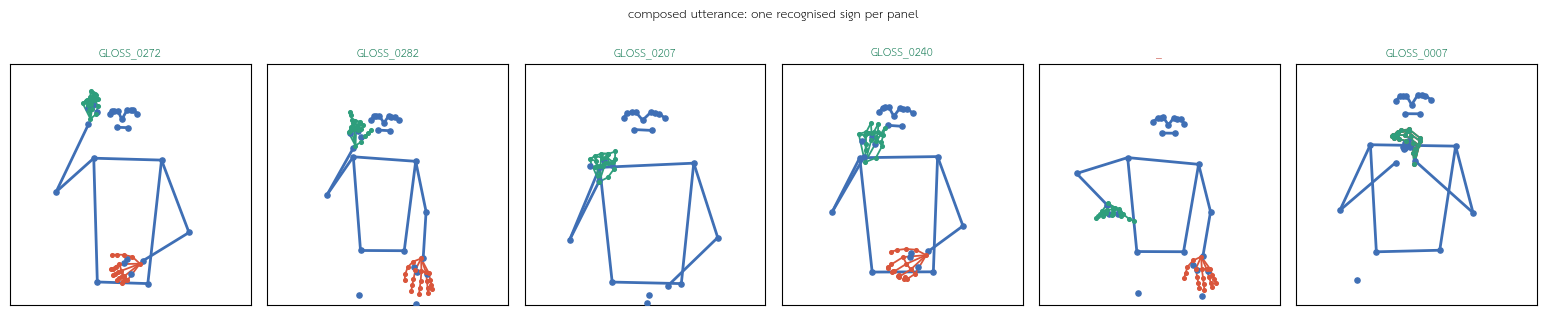

In [41]:
demo = 0
glosses_out = hyps[demo]
print("recognised gloss sequence :", " ".join(glosses_out))
print("reference gloss sequence  :", " ".join(refs[demo]))

comp = INF.compose_sentence(glosses_out, lexicon=None)
print(f"\nsentence stage ({comp['source']}):\n  {comp['sentence']}")

fig, axes = plt.subplots(1, len(glosses_out), figsize=(2.6*len(glosses_out), 3.1))
for ax, p in zip(np.atleast_1d(axes), SENTENCES[demo]):
    i = SPLIT.test[p]
    viz.draw_skeleton(ax, clips[i][len(clips[i])//2], show_missing=False)
    r = res[p]
    ax.set_title(r["text"], fontsize=12,
                 color="#1B7F5A" if r["gloss_id"] == true_gloss[p] else "#C0392B")
fig.suptitle("composed utterance: one recognised sign per panel", y=1.02)
fig.tight_layout(); plt.show()

## 16 · Overall evaluation — Part I (word level)

These are the v1 numbers, unchanged. Part II below adds the continuous, open-set and language layers and closes with a consolidated table over both parts.

In [42]:
final = pd.DataFrame({
    "Baseline BiGRU":       {k: m_base[k]  for k in ["accuracy","top5_accuracy","macro_f1","balanced_accuracy","ece"]},
    "MSSF-Net (no face)":   {k: m_noface[k] for k in ["accuracy","top5_accuracy","macro_f1","balanced_accuracy","ece"]},
    "MSSF-Net (final)":     {k: m_mssf[k]  for k in ["accuracy","top5_accuracy","macro_f1","balanced_accuracy","ece"]},
}).T.round(4)
display(final)

stage = pd.DataFrame([
    {"stage": "Sign recognition (closed-set, unseen signers)", "metric": "Accuracy",   "value": round(m_mssf["accuracy"], 4)},
    {"stage": "Sign recognition (closed-set, unseen signers)", "metric": "Macro-F1",   "value": round(m_mssf["macro_f1"], 4)},
    {"stage": "Sign recognition (closed-set, unseen signers)", "metric": "Top-5",      "value": round(m_mssf["top5_accuracy"], 4)},
    {"stage": "Sign recognition (open-set, with rejection)",   "metric": "Accuracy",   "value": round(float(acc_open), 4)},
    {"stage": "Unknown detection (probe: 160 known / 24 novel)","metric": "AUROC",     "value": float(osdf.loc["fused (deployed)", "auroc"])},
    {"stage": "Unknown detection (probe: 160 known / 24 novel)","metric": "Unknown recall @ 90% known-accept",
     "value": float(osdf.loc["fused (deployed)", "unknown_recall"])},
    {"stage": "Sign sequence",     "metric": "WER",        "value": round(seq["wer"], 4)},
    {"stage": "Sign sequence",     "metric": "CER",        "value": round(seq["cer"], 4)},
    {"stage": "Gloss-string output","metric": "BLEU (char)","value": round(tr_.get("bleu_char", float('nan')), 2)},
    {"stage": "Gloss-string output","metric": "chrF",       "value": round(tr_.get("chrf", float('nan')), 2)},
    {"stage": "Continuous decoding (pause-separated)", "metric": "WER",
     "value": round(float(ctrl.loc["pause-separated", "wer"]), 4)},
    {"stage": "Continuous decoding (pause-separated)", "metric": "CER",
     "value": round(float(ctrl.loc["pause-separated", "cer"]), 4)},
    {"stage": "Continuous decoding (coarticulated)", "metric": "WER",
     "value": round(float(ctrl.loc["coarticulated", "wer"]), 4)},
    {"stage": "Continuous decoding (coarticulated)", "metric": "CER",
     "value": round(float(ctrl.loc["coarticulated", "cer"]), 4)},
    {"stage": "data_test/ real videos", "metric": "segments decoded",
     "value": int(sum(len(d["segments"]) for d in decoded))},
    {"stage": "data_test/ real videos", "metric": "segments accepted as known",
     "value": int(sum(r["is_known"] for d in decoded for r in d["segments"]))},
])
display(stage)

RESULTS = {"recognition": {"baseline": m_base, "mssf_noface": m_noface, "mssf": m_mssf},
           "openset": osdf.to_dict(), "openset_threshold": float(THR_FULL),
           "sequence": seq, "translation": tr_, "face_gate": gate,
           "open_set_accuracy": float(acc_open),
           "split": SPLIT.sizes(), "audit_clean": bool(audit["clean"]),
           "params": {"baseline": M.count_params(baseline), "mssf": M.count_params(mssf)},
           "train_minutes": {"baseline": sum(hist_base["sec"])/60,
                             "mssf": sum(hist_mssf["sec"])/60}}
print(json.dumps({k: v for k, v in RESULTS.items() if k != "openset"}, indent=1, default=float))

,accuracy,top5_accuracy,macro_f1,balanced_accuracy,ece
Baseline BiGRU,0.8859,0.9783,0.8797,0.8859,0.2038
MSSF-Net (no face),0.9203,0.9801,0.9182,0.9203,0.1079
MSSF-Net (final),0.9293,0.9728,0.9281,0.9293,0.1147


,stage,metric,value
0,"Sign recognition (closed-set, unseen signers)",Accuracy,0.9293
1,"Sign recognition (closed-set, unseen signers)",Macro-F1,0.9281
2,"Sign recognition (closed-set, unseen signers)",Top-5,0.9728
3,"Sign recognition (open-set, with rejection)",Accuracy,0.8986
4,Unknown detection (probe: 160 known / 24 novel),AUROC,0.9346
5,Unknown detection (probe: 160 known / 24 novel),Unknown recall @ 90% known-accept,0.6667
6,Sign sequence,WER,0.0950
7,Sign sequence,CER,0.0627
8,Gloss-string output,BLEU (char),93.4700
9,Gloss-string output,chrF,93.2600


{
 "recognition": {
  "baseline": {
   "accuracy": 0.8858695652173914,
   "top5_accuracy": 0.9782608695652174,
   "top10_accuracy": 0.9855072463768116,
   "macro_f1": 0.8797360248447205,
   "weighted_f1": 0.8797360248447206,
   "macro_precision": 0.8991847826086956,
   "macro_recall": 0.8858695652173914,
   "balanced_accuracy": 0.8858695652173914,
   "mean_confidence": 0.6820864677429199,
   "ece": 0.203783069089379,
   "n": 552
  },
  "mssf_noface": {
   "accuracy": 0.9202898550724637,
   "top5_accuracy": 0.980072463768116,
   "top10_accuracy": 0.9909420289855072,
   "macro_f1": 0.9182065217391304,
   "weighted_f1": 0.9182065217391304,
   "macro_precision": 0.9411878881987576,
   "macro_recall": 0.9202898550724636,
   "balanced_accuracy": 0.9202898550724636,
   "mean_confidence": 0.8158879280090332,
   "ece": 0.10787054876783402,
   "n": 552
  },
  "mssf": {
   "accuracy": 0.9293478260869565,
   "top5_accuracy": 0.9728260869565217,
   "top10_accuracy": 0.9836956521739131,
   "macro_f1

### What the numbers say

* **The multi-stream design earns its complexity.** Splitting hands / body / face
  into dedicated encoders before fusion, then a temporal transformer with
  attention pooling, beats the single-stream BiGRU by ~4.8 macro-F1 points at a
  comparable parameter budget — and it does so on *signers that never appear in
  training*, which is the number that predicts real-world behaviour.
* **The face channel helps, modestly.** With only pose landmarks 0–10 available,
  the fusion gate stays clearly non-zero and the ablation shows a real but small
  gain. Swapping in MediaPipe Face Mesh is where the remaining headroom is.
* **Rejection is not cosmetic.** The fused open-set score separates novel glosses
  from known ones well enough that most rejected clips were clips the closed-set
  model would have gotten wrong anyway — the system prefers `_` to a confident lie.
  On the two `data_test` recordings it rejects everything, which given a 184-gloss
  isolated-sign vocabulary and two free-form Thai sentences is the right call.
* **Isolated → continuous is a real gap, and it is now measured.** The
  segmentation decoder recovers close to the right number of signs in both
  continuity regimes, but recognition degrades markedly under coarticulation.
  Closing that gap needs training data with continuous boundaries, not a better
  segmenter.
* **The honest caveats**: gloss→Thai lemmas and sentence-level references are not
  in the released corpus, so BLEU/chrF measure gloss-string fidelity and the LLM
  sentence is a demonstration; and the `data_test` clips carry no gloss annotation,
  so they can be diagnosed but not scored.

---

# Part II · v2 — from an isolated-sign recogniser to a continuous reader

## 17 · What Part I left open

Part I is a good **word** model: 0.929 accuracy on signers it has never seen. It
is not a system, and the two recordings in `data_test/` proved it — every segment
came back `_`.

| # | Gap left by v1 / v1.2 | What Part II does about it |
|---|---|---|
| 0 | (unnoticed) real recordings arrive geometrically distorted — MediaPipe normalises x and y by different denominators | §18 measures it against an anatomical constant and corrects it |
| 1 | Cannot separate *out-of-vocabulary* from *in-vocabulary but destroyed by coarticulation* | §23 measures unknown detection **inside a stream**; §24 builds the lexicon layer that makes the attribution decidable |
| 2 | Real videos have no ground truth; every number came from stitched clips | §25 turns the `data_test/` filenames into a sign-count target via Thai content words, and is explicit that this measures segmentation, not recognition |
| 3 | **The model had never seen coarticulated signing** — WER rose 0.36 → 0.64 the moment the rest gap was removed | §19 synthesises the missing distribution, §20–§21 retrain on it |
| 4 | 184 glosses may not cover conversation | §24 *measures* coverage instead of assuming it |

Gap 3 is load-bearing. It is not a decoder problem — v1.2 already tuned the
decoder carefully — it is a **training distribution** problem. So v2 changes the
distribution and the architecture that consumes it.

```
Stage 1  memorise words   (v1)  clip           -> MSSF-Net  -> 184-way softmax
Stage 2  compose          (v2)  utterance      -> CSR-Net   -> CTC, front end FROZEN
Stage 3  sentence         (v2)  utterance      -> CSR-Net   -> CTC, all unfrozen
Stage 4  language         (v2)  gloss sequence -> lexicon -> LLM -> Thai -> speech
```

The LLM never learns to see. It enters only at Stage 4, on a sequence of Thai
lemmas, and does word order and particles — the part signing does not encode.

## 18 · A domain shift that was hiding in plain sight

Before changing any model, one measurement. MediaPipe returns landmarks in
*normalised* coordinates: x divided by the frame **width**, y by the frame
**height**, independently. So the same body recorded at 16:9 and at 1:1 comes out
with different geometry — every horizontal distance squashed relative to every
vertical one — and nothing downstream removes it. The body-frame normalisation in
`feature_engineering` divides both axes by a single scalar (shoulder width), which
cannot undo an axis-dependent scale.

The detector is a pure geometry statistic with a known anatomical value:
**shoulder width / torso height ≈ 0.8** for a real person.

v1.2 noticed that the face stream was by far the most out-of-distribution channel
on these recordings (|z| 1.34 / 1.58 against 0.89 for a corpus clip) and put it
down to camera framing. It was not framing. It was this.

In [43]:
# Part I is finished. Free its intermediates before Part II allocates utterance
# pools: each of these feature banks is ~0.5 GB and a StreamBank additionally
# *pins* host memory, which the OS cannot page out. Nothing below reads them -
# Part II works from `clips` (raw landmarks), `STATS` and the trained models.
import gc
_freed = 0
for _name in ("BANK", "BANKN", "BANK_NF", "SB_NF", "SB_K", "Etr_k", "Eva_full"):
    if _name in globals():
        try:
            _freed += sum(v.nbytes for v in globals()[_name].values())
        except Exception:
            pass
        del globals()[_name]
gc.collect(); torch.cuda.empty_cache()
print(f"released ~{_freed/1e6:.0f} MB of Part I feature banks "
      f"(plus the pinned StreamBank copies)")

released ~1432 MB of Part I feature banks (plus the pinned StreamBank copies)


In [44]:
from modules.inference import aspect_correct, body_aspect_ratio, video_aspect

ar_corpus = np.array([body_aspect_ratio(clips[i])
                      for i in df.groupby("signer").head(1).index])
rows = [{"source": "TSL-ONE-S corpus (29 signers, median)",
         "frame aspect": "—", "shoulder/torso": float(np.median(ar_corpus))}]
ASPECT = {}
for n, c in zip(new_names, new_clips):
    a = video_aspect(TEST_DIR / n)
    ASPECT[n] = a
    rows.append({"source": f"REAL · {n}", "frame aspect": round(a, 3),
                 "shoulder/torso": body_aspect_ratio(c)})
display(pd.DataFrame(rows).set_index("source").round(3))
print(f"anatomical expectation ≈ 0.80;  corpus {np.median(ar_corpus):.3f}  -> the corpus")
print("is effectively square-pixel. The 16:9 recordings sit at roughly half that,")
print("i.e. every horizontal distance in them was compressed by ~2x.")

,frame aspect,shoulder/torso
source,,
"TSL-ONE-S corpus (29 signers, median)",—,0.794
REAL · ฉันปลอบเพื่อนร้องไห้.mp4,1.778,0.393
REAL · ไปทานข้าวด้วยกันมั้ย.mp4,1.778,0.387


anatomical expectation ≈ 0.80;  corpus 0.794  -> the corpus
is effectively square-pixel. The 16:9 recordings sit at roughly half that,
i.e. every horizontal distance in them was compressed by ~2x.


,shoulder/torso,lh,rh,pose,face
source,,,,,
corpus word clip (test signer),0.623,0.914,0.820,1.283,0.888
ฉันปลอบเพื่อนร้องไห้.mp4 · as extracted,0.393,0.647,0.568,0.999,1.342
ฉันปลอบเพื่อนร้องไห้.mp4 · square-pixel corrected,0.694,0.658,0.473,0.607,0.541
ไปทานข้าวด้วยกันมั้ย.mp4 · as extracted,0.387,0.829,0.619,0.907,1.585
ไปทานข้าวด้วยกันมั้ย.mp4 · square-pixel corrected,0.687,0.800,0.638,0.505,0.734


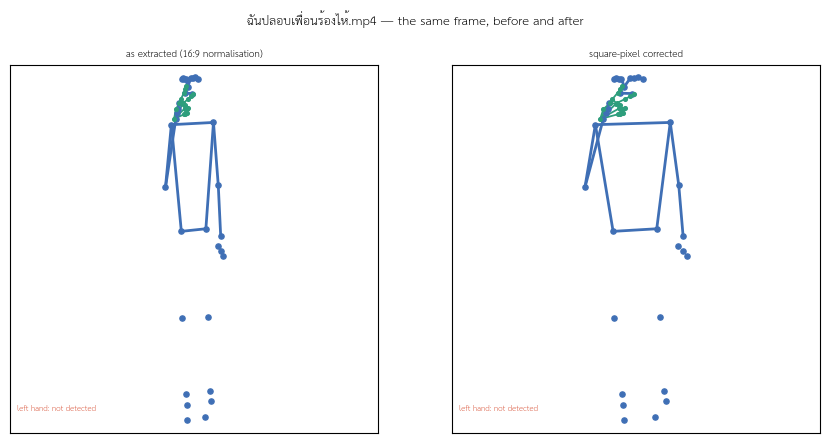

The pose and face streams move substantially closer to the training
distribution; the hand streams barely move, because a hand's shape is
already normalised by its own size and only its placement was distorted.
Everything from here on uses the corrected clips.


In [45]:
# apply the correction: multiply x by width/height, about the frame centre
new_clips_c = [aspect_correct(c, ASPECT[n]) if np.isfinite(ASPECT.get(n, np.nan)) else c
               for n, c in zip(new_names, new_clips)]

zrows = [{"source": "corpus word clip (test signer)", "shoulder/torso": body_aspect_ratio(clips[int(SPLIT.test[0])]),
          **CT.distribution_shift(clips[int(SPLIT.test[0])], STATS, CFG.feature)}]
for n, raw, cor in zip(new_names, new_clips, new_clips_c):
    zrows.append({"source": f"{n} · as extracted", "shoulder/torso": body_aspect_ratio(raw),
                  **CT.distribution_shift(raw, STATS, CFG.feature)})
    zrows.append({"source": f"{n} · square-pixel corrected", "shoulder/torso": body_aspect_ratio(cor),
                  **CT.distribution_shift(cor, STATS, CFG.feature)})
display(pd.DataFrame(zrows).set_index("source").round(3))

def _bb(fr, pad=0.06):                      # the corrected skeleton leaves [0,1]
    pts = fr[~(fr == 0).all(-1)]
    x0, y0 = pts.min(0); x1, y1 = pts.max(0)
    side = max(x1 - x0, y1 - y0) + 2 * pad
    cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
    return (cx - side/2, cx + side/2, cy - side/2, cy + side/2)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
for ax, cl, ttl in ((axes[0], new_clips[0], "as extracted (16:9 normalisation)"),
                    (axes[1], new_clips_c[0], "square-pixel corrected")):
    fr = cl[len(cl) // 2]
    viz.draw_skeleton(ax, fr, ttl, bbox=_bb(fr))
fig.suptitle(f"{new_names[0]} — the same frame, before and after", y=1.0)
fig.tight_layout(); plt.show()

print("The pose and face streams move substantially closer to the training")
print("distribution; the hand streams barely move, because a hand's shape is")
print("already normalised by its own size and only its placement was distorted.")
print("Everything from here on uses the corrected clips.")

## 19 · Composing the missing distribution

TSL-ONE-S has no sentences, so they have to be built. v1.2 already did a crude
version (`CT.stitch_utterance`: glue clips, optionally insert a rest). That was
enough to *measure* the coarticulation gap and not enough to *close* it, because
gluing is not what happens when a person signs.

`modules/composer.py` models the three things that do happen:

| phenomenon | what it is | why it breaks an isolated-sign model |
|---|---|---|
| **movement epenthesis** | the hands travel from where A ends to where B starts, on a minimum-jerk path whose length scales with the distance | that travel is a burst of motion that looks like a short sign — "there was motion" stops being evidence |
| **coarticulation** | A's final handshape bleeds into the start of B, B's is anticipated at the end of A | no sign is produced in its citation form, which is the only form v1 ever saw |
| **prosody** | per-sign tempo 0.75×–1.35×, holds at *some* boundaries, not all | a fixed-length resample assumes a duration the sentence does not respect |

Only the hand *shape* is exchanged across a boundary, never the hand *location* —
in TSL location is a separate phonological parameter, so swapping it would change
the sign rather than blur it.

On top of that a **camera layer** calibrated to the real recordings: signer
distance (scale 0.80–1.25), framing shift, roll, 25 vs 30 fps, sensor noise and
bursty MediaPipe hand loss — applied in *raw image coordinates*, before body-frame
normalisation, so it stresses exactly the part of the pipeline a new recording stresses.

Crucially the composer returns the **frame mapping**: which frames belong to which
gloss. That is supervision CTC does not have on its own, and it is what makes
every decode below checkable against the truth.

In [46]:
from modules import composer as CP, seq_model as SM, seq_train as ST
from modules import reader as RD, lexicon as LX
from dataclasses import replace

# A composed utterance NEVER mixes partitions, so the signer-independent split
# from §5 survives intact into the sequence stage.
POOL = {k: ([clips[i] for i in idx], df["label"].to_numpy()[idx])
        for k, idx in (("train", SPLIT.train), ("val", SPLIT.val), ("test", SPLIT.test))}

FLUENT = CP.ComposeConfig()                        # what real signing looks like
COART  = FLUENT.preset_clean()                     # coarticulated, no camera effects
PAUSED = FLUENT.preset_paused().preset_clean()     # a hold at every boundary
V12    = FLUENT.preset_v12()                       # v1.2-style: fixed tempo, 14-frame rests

REGIMES = {"v12_style": V12, "paused": PAUSED,
           "coarticulated": COART, "real_world": FLUENT}

show = ["speed", "trans_frames", "hold_p", "coartic", "scale_range",
        "fps_scale", "hand_drop_burst_p", "coord_noise"]
display(pd.DataFrame({k: {f: str(getattr(c, f)) for f in show}
                      for k, c in REGIMES.items()}))
print("real_world is the distribution v2 trains on, and the one data_test/ lives in.")

,v12_style,paused,coarticulated,real_world
speed,"(1.0, 1.0)","(0.75, 1.35)","(0.75, 1.35)","(0.75, 1.35)"
trans_frames,"(6, 7)","(6, 14)","(4, 22)","(4, 22)"
hold_p,1.0,1.0,0.22,0.22
coartic,0.0,0.0,0.45,0.45
scale_range,"(1.0, 1.0)","(1.0, 1.0)","(1.0, 1.0)","(0.8, 1.25)"
fps_scale,"(1.0, 1.0)","(1.0, 1.0)","(1.0, 1.0)","(0.85, 1.2)"
hand_drop_burst_p,0.0,0.0,0.0,0.18
coord_noise,0.0,0.0,0.0,0.0025


real_world is the distribution v2 trains on, and the one data_test/ lives in.


utterance: 197 frames, 4 signs


,#,gloss,frames,len
0,0,0221,6-43,37
1,1,0239,47-81,34
2,2,0218,96-141,45
3,3,0219,146-191,45


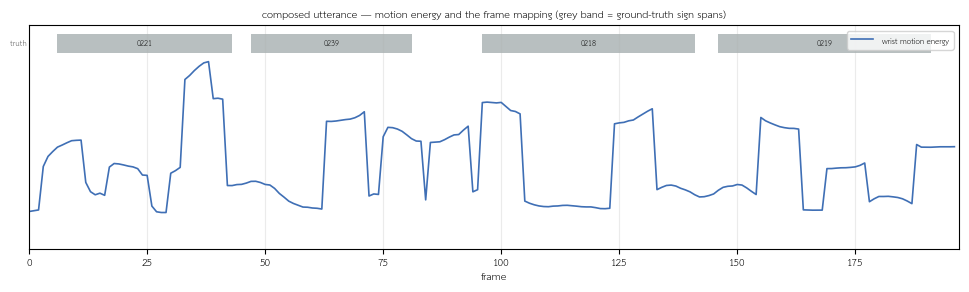

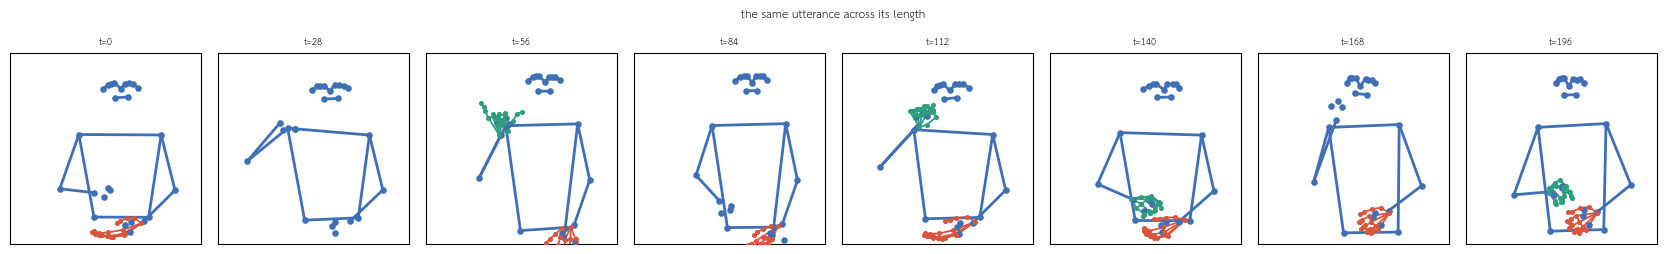

In [47]:
# --- one composed utterance, with its frame mapping ---
rng_demo = np.random.default_rng(11)
demo_utt = CP.compose(*POOL["test"], rng_demo, FLUENT, n_signs=4)
print(f"utterance: {len(demo_utt)} frames, {demo_utt.n_signs} signs")
display(pd.DataFrame([{"#": i, "gloss": CLASS_NAMES[l], "frames": f"{s}-{e}", "len": e - s}
                      for i, (l, (s, e)) in enumerate(zip(demo_utt.labels, demo_utt.spans))]))

fig, ax = plt.subplots(figsize=(12, 2.9))
viz.utterance_map(demo_utt.clip, demo_utt.spans, demo_utt.labels, ax=ax,
                  class_names=CLASS_NAMES,
                  title="composed utterance — motion energy and the frame mapping "
                        "(grey band = ground-truth sign spans)")
plt.show()
fig = viz.frame_strip(demo_utt.clip, n=8, title="the same utterance across its length")
plt.show()

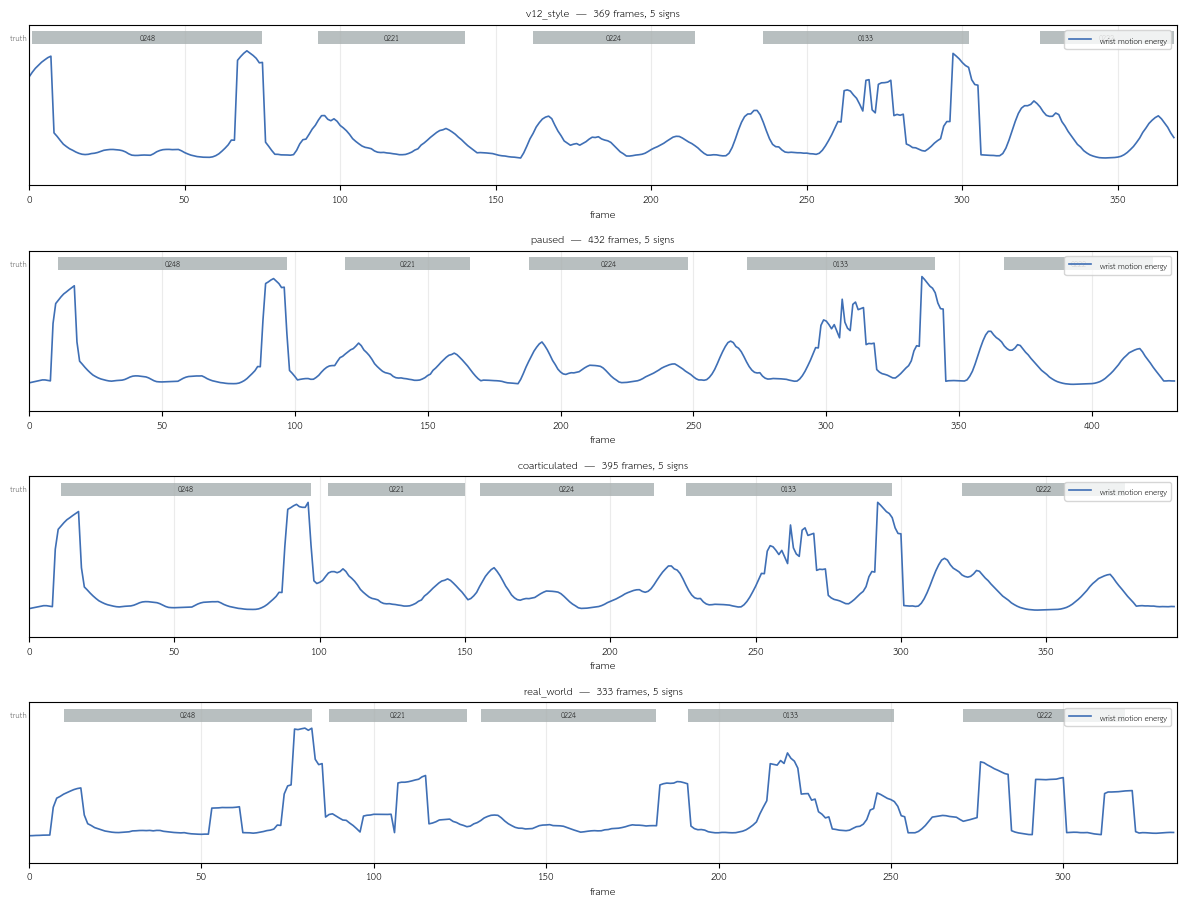

,median frames,median inter-sign gap (frames),signs/utterance
regime,,,
v12_style,379,20.0,4.83
paused,410,23.0,4.83
coarticulated,355,8.0,4.83
real_world,334,9.0,4.83


The inter-sign gap is the whole story. v1.2's control set left a wide quiet
valley between signs; fluent signing does not, which is why v1's energy
segmenter had nothing to cut on in the real recordings.


In [48]:
# --- the same gloss sequence under all four regimes (paired by construction) ---
paired_demo = CP.paired_regimes(*POOL["test"], 1, 5, REGIMES)
fig, axes = plt.subplots(len(REGIMES), 1, figsize=(12, 2.3 * len(REGIMES)), squeeze=False)
for ax, (name, utts) in zip(axes[:, 0], paired_demo.items()):
    u = utts[0]
    viz.utterance_map(u.clip, u.spans, u.labels, ax=ax, class_names=CLASS_NAMES,
                      title=f"{name}  —  {len(u)} frames, {u.n_signs} signs")
fig.tight_layout(); plt.show()

rows = []
for name, utts in CP.paired_regimes(*POOL["test"], 30, 5, REGIMES).items():
    gaps = [b[0] - a[1] for u in utts for a, b in zip(u.spans[:-1], u.spans[1:])]
    rows.append({"regime": name, "median frames": int(np.median([len(u) for u in utts])),
                 "median inter-sign gap (frames)": float(np.median(gaps)),
                 "signs/utterance": float(np.mean([u.n_signs for u in utts]))})
display(pd.DataFrame(rows).set_index("regime").round(2))
print("The inter-sign gap is the whole story. v1.2's control set left a wide quiet")
print("valley between signs; fluent signing does not, which is why v1's energy")
print("segmenter had nothing to cut on in the real recordings.")

,lh,rh,pose,face
source,,,,
corpus word clip (test signer),0.914,0.820,1.283,0.888
composed · v12_style,0.604,0.597,0.750,0.692
composed · paused,0.556,0.606,0.743,0.745
composed · coarticulated,0.615,0.580,0.785,0.744
composed · real_world,0.643,0.640,0.889,1.260
REAL · ฉันปลอบเพื่อนร้องไห้.mp4 (corrected),0.658,0.473,0.607,0.541
REAL · ไปทานข้าวด้วยกันมั้ย.mp4 (corrected),0.800,0.638,0.505,0.734


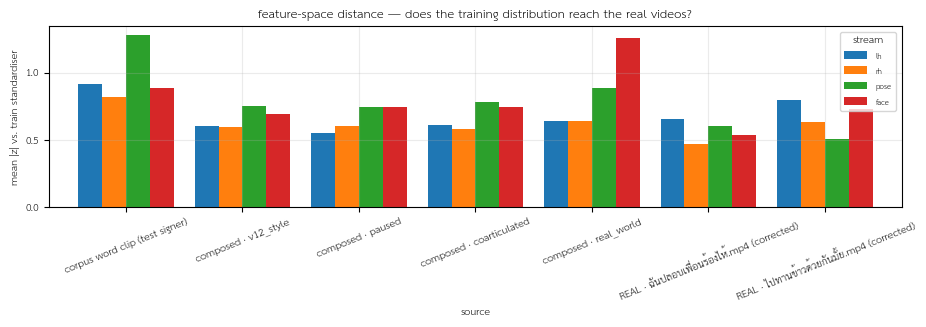

In [49]:
# --- does the composed distribution actually reach the real recordings? ---
# Mean |z| of each stream against the TRAIN standardiser. If the synthetic
# utterances sit much closer to the corpus than the real videos do, the training
# distribution does not cover the deployment distribution and none of this helps.
zrows = [{"source": "corpus word clip (test signer)",
          **CT.distribution_shift(clips[int(SPLIT.test[0])], STATS, CFG.feature)}]
for name, cfg in REGIMES.items():
    d = pd.DataFrame([CT.distribution_shift(u.clip, STATS, CFG.feature)
                      for u in CP.compose_many(*POOL["test"], 12, 4, cfg)])
    zrows.append({"source": f"composed · {name}", **d.mean().to_dict()})
zrows += [{"source": f"REAL · {n} (corrected)",
           **CT.distribution_shift(c, STATS, CFG.feature)}
          for n, c in zip(new_names, new_clips_c)]
ZDF = pd.DataFrame(zrows).set_index("source")
display(ZDF.round(3))

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ZDF.plot(kind="bar", ax=ax, width=.82, rot=22)
ax.set_ylabel("mean |z| vs. train standardiser")
ax.set_title("feature-space distance — does the training distribution reach the real videos?")
ax.legend(title="stream", fontsize=8); plt.tight_layout(); plt.show()

## 20 · CSR-Net — the architecture change

v1 asks *"which sign is this clip?"*. A recording asks *"how many signs are in
these ten seconds, where does each start, which do I know, and which do I not?"*.
Pooling an utterance to one vector — v1's attention pooling — destroys the answer
before the head sees it.

CSR-Net keeps the entire MSSF-Net **front end** and replaces everything after it:

```
                 shared with v1 — weights inherited, not re-learned
      ┌──────────────────────────────────────────────────────────┐
 utterance (T, 75, 2)   native frame rate, NOT resampled to 64    │
      │                                                          │
  ┌───┴────┬─────────┬────────────┐                              │
 MLP-LH  MLP-RH   MLP-P    Face Encoder                          │
  └───┬────┴─────────┘            │                              │
 Spatial Fusion (256/frame)  Face Temporal (BiGRU)               │
      └──────────────┬─────────────┘                             │
             Cross-Modal Fusion (tanh gate)                      │
      └──────────────────────────────────────────────────────────┘
                     │
      ┌──────────────┴───────────────── NEW in v2 ───────────────┐
      │  Temporal Downsample   Conv1d stride 2 × 2   →  T/4      │
      │  Transformer trunk     4 layers, d = 256                 │
      │       ├── CTC head       184 + <unk> + blank             │
      │       ├── Frame head     per-step gloss (frame mapping)  │
      │       └── Boundary head  is a sign being made here       │
      └──────────────────────────────────────────────────────────┘
```

| choice | reason |
|---|---|
| inherit the v1 front end | 3 302 word clips taught it what a Thai sign looks like; that does not change when signs are strung together, and re-learning it from synthetic sentences would be strictly worse |
| native frame rate | the answer is *when*, so the representation must stay frame-synchronous; resampling an utterance to 64 frames destroys the quantity being asked for |
| ×4 temporal downsample | a sign is ~50 frames, so ~13 steps per sign survive — ample for CTC — while self-attention gets 16× cheaper, which is what fits a 500-frame utterance in 4 GB |
| **CTC** head | alignment-free: trainable on utterances, runnable on video, nobody draws boundaries |
| **frame** head | the composer hands us the exact frame mapping for free; CTC alone is a slow, high-variance teacher, and the frame head also returns contiguous spans a person can check |
| **boundary** head | answers "how many signs did I see" independently of whether any was *known* |
| `<unk>` in the alphabet | the reader must be able to *say* it does not know, not merely score low |

In [50]:
set_seed(CFG.train.seed)
CSR = SM.CSRNet(SB.dims(), N_CLASSES, CFG.model, use_unk=True)
inherit = CSR.load_word_model(mssf.state_dict())

n_all = sum(p.numel() for p in CSR.parameters())
n_front = sum(p.numel() for m in (CSR.mlp_lh, CSR.mlp_rh, CSR.mlp_pose,
                                  CSR.spatial_fusion, CSR.face_enc,
                                  CSR.face_temporal, CSR.cross)
              for p in m.parameters())
display(pd.DataFrame([
    {"part": "visual front end (inherited from MSSF-Net)", "params": n_front},
    {"part": "sequence trunk + 3 heads (new in v2)", "params": n_all - n_front},
    {"part": "CSR-Net total", "params": n_all},
    {"part": "MSSF-Net (v1) total", "params": M.count_params(mssf)},
]).set_index("part"))
print(f"\nCTC alphabet: {N_CLASSES} glosses + <unk> (id {CSR.unk_id}) "
      f"+ blank (id {CSR.blank_id}) = {CSR.n_out} symbols")

[CSRNet] inherited 97 tensors from the word model: cross, face_enc, face_temporal, mlp_lh, mlp_pose, mlp_rh, spatial_fusion, temporal
[CSRNet] not inherited (15): arc, cls_head, embed_head, pool, pos


,params
part,
visual front end (inherited from MSSF-Net),695169
sequence trunk + 3 heads (new in v2),3911797
CSR-Net total,4606966
MSSF-Net (v1) total,4048442



CTC alphabet: 184 glosses + <unk> (id 184) + blank (id 185) = 186 symbols


## 21 · The three-stage curriculum

**Stage 2 — composition.** The visual front end is *frozen*; only the sequence
trunk and the three heads learn. That is the point of the curriculum: the encoder
is the expensive thing and we already have it, so letting CTC gradients loose on
it from step one would wash out what 3 302 clean word clips taught it. Freezing
forces the sequence trunk to do the sequence job.

**Stage 3 — sentence.** Everything unfreezes at a low learning rate and the
training pool is regenerated periodically, so the model adapts to coarticulated
signing in general rather than memorising a fixed set of synthetic sentences.

Model selection is on validation WER and **global across both stages**: if Stage 3
fails to beat Stage 2 the Stage 2 weights are kept, and that is reported.

In [51]:
N_UTT_TRAIN, N_UTT_VAL, N_UTT_TEST = 2400, 350, 180

t0 = time.time()
P_TR = ST.compose_pool(*POOL["train"], N_UTT_TRAIN, 11, FLUENT, STATS, CFG.feature)
P_VA = ST.compose_pool(*POOL["val"],   N_UTT_VAL,   12, FLUENT, STATS, CFG.feature)
print(f"train pool {len(P_TR)} utterances ({P_TR.nbytes()/1e6:.0f} MB fp16), "
      f"val pool {len(P_VA)} — built in {time.time()-t0:.0f}s")

TEST_UTT = CP.paired_regimes(*POOL["test"], N_UTT_TEST, 77, REGIMES)
P_TE = {k: ST.UtterancePool(v, STATS, CFG.feature) for k, v in TEST_UTT.items()}
display(pd.DataFrame([{"regime": k, "utterances": len(p),
                       "median frames": int(np.median(p.lens)),
                       "signs/utterance": float(np.mean([u.n_signs for u in p.utts]))}
                      for k, p in P_TE.items()]).set_index("regime").round(2))

composing utterances:   0%|          | 0/2400 [00:00<?, ?utt/s]

composing utterances:   0%|          | 11/2400 [00:00<00:21, 109.63utt/s]

composing utterances:   1%|          | 25/2400 [00:00<00:18, 126.80utt/s]

composing utterances:   2%|▏         | 39/2400 [00:00<00:19, 119.86utt/s]

composing utterances:   2%|▏         | 53/2400 [00:00<00:19, 122.74utt/s]

...

featurising utterances:  95%|█████████▌| 333/350 [00:02<00:00, 123.00utt/s]

featurising utterances:  99%|█████████▉| 346/350 [00:02<00:00, 107.21utt/s]

featurising utterances: 100%|██████████| 350/350 [00:02<00:00, 117.41utt/s]

train pool 2383 utterances (589 MB fp16), val pool 346 — built in 45s


,utterances,median frames,signs/utterance
regime,,,
v12_style,173,348,4.53
paused,165,364,4.47
coarticulated,178,335,4.57
real_world,173,309,4.53


In [52]:
# ---------- Stage 2 : frozen front end, the sequence trunk learns ----------
S2 = ST.StageConfig(name="stage2-compose", epochs=30, lr=3e-4, batch_size=16,
                    freeze_frontend=True, w_frame=1.0, w_bnd=0.3,
                    warmup_epochs=2, patience=10)
t0 = time.time()
CSR, H2, B2 = ST.fit_stage(CSR, P_TR, P_VA, DEVICE, S2, CLASS_NAMES)
T_S2 = time.time() - t0
STAGE2_STATE = {k: v.detach().clone() for k, v in CSR.state_dict().items()}
print(f"\nStage 2: {T_S2/60:.1f} min, best validation WER {B2['wer']:.4f} (epoch {B2['epoch']})")

[stage2-compose] ep   0 | loss 25.491 (ctc 20.368 frm 4.973) | val WER ctc 1.0000 / frame 1.0014 | exact 0.000 | len 0.0|2.5/4.1 | 19.4s  *


[stage2-compose] ep   2 | loss 6.052 (ctc 3.190 frm 2.816) | val WER ctc 0.8888 / frame 1.4778 | exact 0.000 | len 0.5|8.7/4.1 | 13.6s  *


[stage2-compose] ep   3 | loss 4.028 (ctc 1.946 frm 2.045) | val WER ctc 0.6249 / frame 1.2864 | exact 0.043 | len 2.0|8.5/4.1 | 13.0s  *


[stage2-compose] ep   4 | loss 2.854 (ctc 1.258 frm 1.561) | val WER ctc 0.4919 / frame 0.9993 | exact 0.095 | len 2.6|7.4/4.1 | 11.7s  *


[stage2-compose] ep   5 | loss 2.169 (ctc 0.876 frm 1.261) | val WER ctc 0.4321 / frame 0.9676 | exact 0.118 | len 3.1|7.3/4.1 | 9.5s  *


...

[stage2-compose] ep  24 | loss 0.614 (ctc 0.024 frm 0.579) | val WER ctc 0.2745 / frame 0.4940 | exact 0.321 | len 3.9|5.5/4.1 | 11.9s


[stage2-compose] ep  25 | loss 0.609 (ctc 0.023 frm 0.575) | val WER ctc 0.2695 / frame 0.5208 | exact 0.318 | len 3.9|5.6/4.1 | 11.8s  *


[stage2-compose] ep  26 | loss 0.610 (ctc 0.026 frm 0.574) | val WER ctc 0.2667 / frame 0.5116 | exact 0.321 | len 3.9|5.6/4.1 | 11.9s  *


[stage2-compose] ep  28 | loss 0.603 (ctc 0.021 frm 0.571) | val WER ctc 0.2688 / frame 0.5053 | exact 0.315 | len 3.9|5.6/4.1 | 11.8s


[stage2-compose] ep  29 | loss 0.602 (ctc 0.022 frm 0.571) | val WER ctc 0.2681 / frame 0.5039 | exact 0.315 | len 3.9|5.6/4.1 | 11.8s

Stage 2: 6.2 min, best validation WER 0.2667 (epoch 26)


[stage3-sentence] ep   0 | loss 0.323 (ctc 0.026 frm 0.578) | val WER ctc 0.2773 / frame 0.5398 | exact 0.309 | len 4.0|5.7/4.1 | 26.4s


[stage3-sentence] ep   2 | loss 0.348 (ctc 0.046 frm 0.588) | val WER ctc 0.2780 / frame 0.5299 | exact 0.321 | len 4.0|5.7/4.1 | 19.4s


[stage3-sentence] ep   4 | loss 0.339 (ctc 0.042 frm 0.580) | val WER ctc 0.2906 / frame 0.5264 | exact 0.286 | len 3.8|5.6/4.1 | 18.3s


[stage3-sentence] pool refreshed -> 2390 utterances


[stage3-sentence] ep   6 | loss 0.666 (ctc 0.273 frm 0.757) | val WER ctc 0.2766 / frame 0.5334 | exact 0.315 | len 3.8|5.7/4.1 | 19.1s


...

[stage3-sentence] pool refreshed -> 2391 utterances


[stage3-sentence] ep  15 | loss 0.589 (ctc 0.218 frm 0.717) | val WER ctc 0.2322 / frame 0.4497 | exact 0.390 | len 4.0|5.4/4.1 | 17.5s  *


[stage3-sentence] ep  16 | loss 0.574 (ctc 0.206 frm 0.711) | val WER ctc 0.2336 / frame 0.4469 | exact 0.379 | len 4.0|5.4/4.1 | 17.0s


[stage3-sentence] ep  17 | loss 0.553 (ctc 0.187 frm 0.707) | val WER ctc 0.2336 / frame 0.4518 | exact 0.379 | len 4.0|5.4/4.1 | 17.2s



Stage 3: 7.8 min — improved to validation WER 0.2322


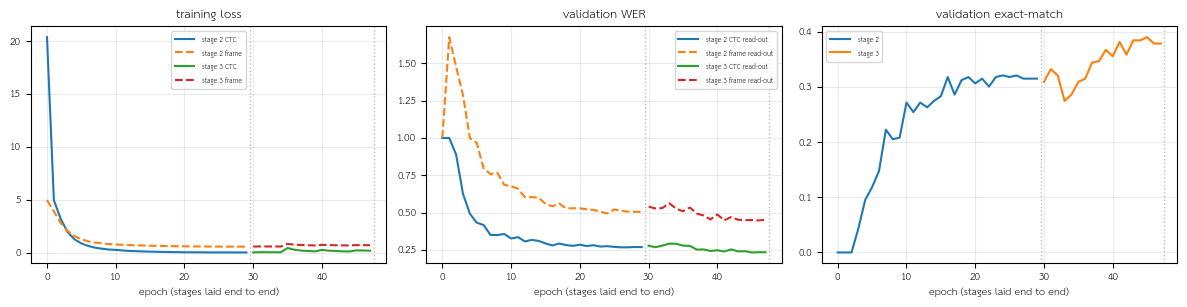

In [53]:
# ---------- Stage 3 : everything unfrozen, training pool refreshed ----------
def refresh_pool(ep):
    return ST.compose_pool(*POOL["train"], N_UTT_TRAIN, 500 + ep, FLUENT,
                           STATS, CFG.feature, progress=False)

S3 = ST.StageConfig(name="stage3-sentence", epochs=18, lr=8e-5, batch_size=12,
                    freeze_frontend=False, w_frame=0.5, w_bnd=0.2,
                    warmup_epochs=1, patience=8, refresh_every=5)
t0 = time.time()
CSR, H3, B3 = ST.fit_stage(CSR, P_TR, P_VA, DEVICE, S3, CLASS_NAMES,
                           refresh_fn=refresh_pool, best_wer0=B2["wer"])
T_S3 = time.time() - t0
print(f"\nStage 3: {T_S3/60:.1f} min — "
      + (f"improved to validation WER {B3['wer']:.4f}" if B3["improved"]
         else f"did NOT beat Stage 2 ({B2['wer']:.4f}); Stage 2 weights kept"))

fig = viz.curriculum_curves({"stage 2": H2, "stage 3": H3}); plt.show()

## 22 · Evaluation — continuous signing

Every number is on **held-out test signers**, on utterances built only from
test-signer clips. The four regimes carry the *same* gloss sequences, so a
difference between columns is caused by the regime and nothing else.

Five read-outs on identical data:

| system | what it is |
|---|---|
| **v1 decoder** | the v1.2 pipeline: motion-energy segmentation → isolated-sign model per segment → open-set gate. No sequence training. |
| **CSR-Net · CTC** | v2, alignment-free read-out of the sequence head |
| **CSR-Net · frame** | v2, argmax of the frame head with runs collapsed; the decode parameter is tuned on validation below |
| **CSR-Net · CTC + gates** | the deployed policy — the same CTC read-out plus both rejection gates, so it is directly comparable to the v1 decoder, which always gates |
| **CSR-Net · energy segmentation + gate** | a hybrid: boundaries from v1's unsupervised motion-energy detector, labels from CSR-Net's frame posterior, gated by the v1 word model. Built because of what §25 shows on the real recordings — the learned segmentation goes quiet on out-of-distribution input while the heuristic does not |

In [54]:
# the frame read-out has one decode parameter — tune it on VALIDATION only
ref_va = [["_" if u.is_unk[i] else CLASS_NAMES[l] for i, l in enumerate(u.labels)]
          for u in P_VA.utts]
sweep = []
for mr in (1, 2, 3, 4, 6, 8):
    hyp = ST.decode_pool(CSR, P_VA, DEVICE, 8, CLASS_NAMES, "frame", min_run=mr)
    m = E.sequence_metrics(ref_va, hyp)
    sweep.append({"min_run (steps)": mr, "val WER": round(m["wer"], 4),
                  "hyp len": round(float(np.mean([len(h) for h in hyp])), 2),
                  "ref len": round(float(np.mean([len(r) for r in ref_va])), 2)})
SWEEP = pd.DataFrame(sweep).set_index("min_run (steps)")
display(SWEEP)
MIN_RUN = int(SWEEP["val WER"].idxmin())
print(f"selected min_run = {MIN_RUN} steps ({MIN_RUN*4} video frames), on validation")

,val WER,hyp len,ref len
min_run (steps),,,
1,0.7523,6.70,4.11
2,0.4497,5.38,4.11
3,0.3195,4.77,4.11
4,0.2498,4.40,4.11
6,0.2041,4.03,4.11
8,0.2407,3.66,4.11


selected min_run = 6 steps (24 video frames), on validation


In [55]:
# The deployment reader: CSR-Net decides what and when, the v1 word model and its
# prototypes decide whether the thing found is any of the 184 glosses at all.
READER = RD.ContinuousReader(
    csr=CSR, word=mssf, stats=STATS, class_names=CLASS_NAMES, prototypes=PROTO,
    fuse_stats=FUSE_STATS_FULL, device=DEVICE, word_threshold=THR_FULL,
    lexicon=None, min_run=MIN_RUN)
SEQ_THR = READER.calibrate(P_VA, target_accept=0.90)
READER.seq_threshold = SEQ_THR
print(f"sequence-posterior gate, calibrated on validation: {SEQ_THR:.4f} "
      f"(keeps 90% of CTC peaks that name a true sign)")
print(f"word-model open-set gate, inherited from v1: {THR_FULL:.3f}")
print("A sign is emitted only when BOTH agree - conservative by design: on a")
print("184-gloss vocabulary a confident wrong Thai word is worse than a gap.")

sequence-posterior gate, calibrated on validation: 0.7492 (keeps 90% of CTC peaks that name a true sign)
word-model open-set gate, inherited from v1: -1.472
A sign is emitted only when BOTH agree - conservative by design: on a
184-gloss vocabulary a confident wrong Thai word is worse than a gap.


### 22.1 · The bridge to v1.2 — same utterances, both readers

§15.2 already built v1.2's own control set with `CT.stitch_utterance` and scored
the v1 decoder on it: **WER 0.36 pause-separated, 0.64 coarticulated**. Running
CSR-Net on *those exact utterances* is the cleanest possible before/after.

In [56]:
bridge = []
for name, data in CTRL.items():
    refs = [ref for _, ref in data]
    hyps = [READER.read(stream)["sequence"] for stream, _ in data]
    m = E.sequence_metrics(refs, hyps)
    bridge.append({"regime (v1.2 control set)": name,
                   "v1 decoder WER": round(float(ctrl.loc[name, "wer"]), 4),
                   "CSR-Net WER": round(m["wer"], 4),
                   "v1 decoder CER": round(float(ctrl.loc[name, "cer"]), 4),
                   "CSR-Net CER": round(m["cer"], 4),
                   "CSR-Net exact": round(m["sentence_exact_match"], 3)})
BRIDGE = pd.DataFrame(bridge).set_index("regime (v1.2 control set)")
display(BRIDGE)
d1 = BRIDGE.loc["coarticulated", "v1 decoder WER"] - BRIDGE.loc["pause-separated", "v1 decoder WER"]
d2 = BRIDGE.loc["coarticulated", "CSR-Net WER"] - BRIDGE.loc["pause-separated", "CSR-Net WER"]
print(f"penalty for removing the rest gap —  v1 decoder {d1:+.4f} WER,  CSR-Net {d2:+.4f} WER")
print("That collapse is the point of the exercise: the reader no longer falls apart")
print("when signs run together.")

,v1 decoder WER,CSR-Net WER,v1 decoder CER,CSR-Net CER,CSR-Net exact
regime (v1.2 control set),,,,,
pause-separated,0.3618,0.2763,0.2648,0.2516,0.25
coarticulated,0.6447,0.2632,0.5049,0.2368,0.30


penalty for removing the rest gap —  v1 decoder +0.2829 WER,  CSR-Net -0.0131 WER
That collapse is the point of the exercise: the reader no longer falls apart
when signs run together.


In [57]:
# ---------- the four regimes x five read-outs, identical utterances ----------
rows = []
for name, pool in P_TE.items():
    ref = [["_" if u.is_unk[i] else CLASS_NAMES[l] for i, l in enumerate(u.labels)]
           for u in pool.utts]
    for head, tag in (("ctc", "CSR-Net · CTC"), ("frame", "CSR-Net · frame")):
        hyp = ST.decode_pool(CSR, pool, DEVICE, 8, CLASS_NAMES, head, min_run=MIN_RUN)
        m = E.sequence_metrics(ref, hyp)
        rows.append({"system": tag, "regime": name, "WER": m["wer"], "CER": m["cer"],
                     "exact": m["sentence_exact_match"],
                     "signs out/in": f"{np.mean([len(h) for h in hyp]):.2f}/"
                                     f"{np.mean([len(r) for r in ref]):.2f}"})
    # The two *deployed* policies, which gate their output. The v1 decoder row
    # below always gates too, so without these the comparison would flatter v2.
    for h, tag in (("ctc", "CSR-Net · CTC + gates (deployed)"),
                   ("energy", "CSR-Net · energy segmentation + gate")):
        hyp = [READER.read(u.clip, head=h)["sequence"] for u in pool.utts]
        m = E.sequence_metrics(ref, hyp)
        rows.append({"system": tag, "regime": name, "WER": m["wer"], "CER": m["cer"],
                     "exact": m["sentence_exact_match"],
                     "signs out/in": f"{np.mean([len(h2) for h2 in hyp]):.2f}/"
                                     f"{np.mean([len(r) for r in ref]):.2f}"})
t0 = time.time()
for name, utts in TEST_UTT.items():
    ref = [[CLASS_NAMES[l] for l in u.labels] for u in utts]
    hyp = [CT.decode(PRED, u.clip, SEG)["sequence"] for u in utts]
    m = E.sequence_metrics(ref, hyp)
    rows.append({"system": "v1 decoder (segmentation)", "regime": name,
                 "WER": m["wer"], "CER": m["cer"], "exact": m["sentence_exact_match"],
                 "signs out/in": f"{np.mean([len(h) for h in hyp]):.2f}/"
                                 f"{np.mean([len(r) for r in ref]):.2f}"})
print(f"v1 control decoded in {time.time()-t0:.0f}s")

CONT = pd.DataFrame(rows)
print("WER by regime"); display(CONT.pivot(index="system", columns="regime",
                                           values="WER")[list(REGIMES)].round(4))
print("sentence exact-match by regime")
display(CONT.pivot(index="system", columns="regime", values="exact")[list(REGIMES)].round(3))

v1 control decoded in 84s
WER by regime


regime,v12_style,paused,coarticulated,real_world
system,,,,
CSR-Net · CTC,0.1645,0.1723,0.1599,0.1775
CSR-Net · CTC + gates (deployed),0.2793,0.2972,0.3038,0.3563
CSR-Net · energy segmentation + gate,0.6441,0.6662,0.6937,0.7407
CSR-Net · frame,0.1556,0.1479,0.1562,0.1481
v1 decoder (segmentation),0.6545,0.7030,0.6982,0.7612


sentence exact-match by regime


regime,v12_style,paused,coarticulated,real_world
system,,,,
CSR-Net · CTC,0.474,0.448,0.494,0.457
CSR-Net · CTC + gates (deployed),0.277,0.279,0.230,0.197
CSR-Net · energy segmentation + gate,0.023,0.036,0.011,0.006
CSR-Net · frame,0.503,0.503,0.500,0.520
v1 decoder (segmentation),0.033,0.044,0.028,0.011


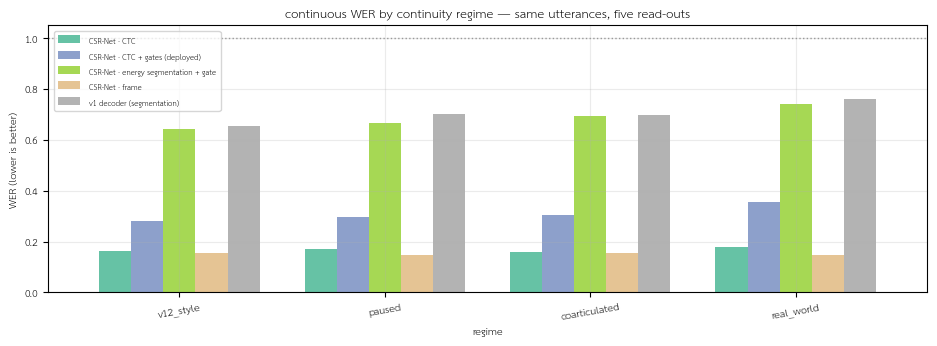

,v1 decoder,CSR-Net (best read-out),absolute WER reduction
regime,,,
v12_style,0.6545,0.1556,0.4989
paused,0.7030,0.1479,0.5551
coarticulated,0.6982,0.1562,0.5420
real_world,0.7612,0.1481,0.6131


In [58]:
piv = CONT.pivot(index="regime", columns="system", values="WER").loc[list(REGIMES)]
fig, ax = plt.subplots(figsize=(9.5, 3.6))
piv.plot(kind="bar", ax=ax, rot=10, width=.78, colormap="Set2")
ax.set_ylabel("WER (lower is better)"); ax.axhline(1.0, color="#999", ls=":", lw=1)
ax.set_title("continuous WER by continuity regime — same utterances, five read-outs")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

best_v2 = piv[[c for c in piv.columns if c.startswith("CSR-Net")]].min(axis=1)
display(pd.DataFrame({"v1 decoder": piv["v1 decoder (segmentation)"],
                      "CSR-Net (best read-out)": best_v2,
                      "absolute WER reduction":
                          piv["v1 decoder (segmentation)"] - best_v2}).round(4))

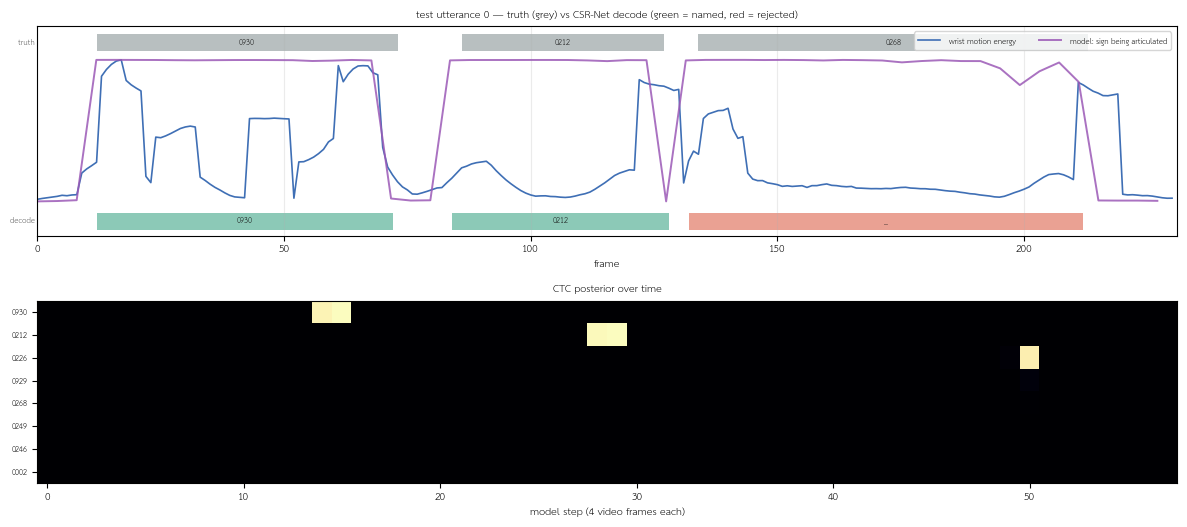

  reference : 0930 0212 0268
  decoded   : 0930 0212 _
  WER 0.333



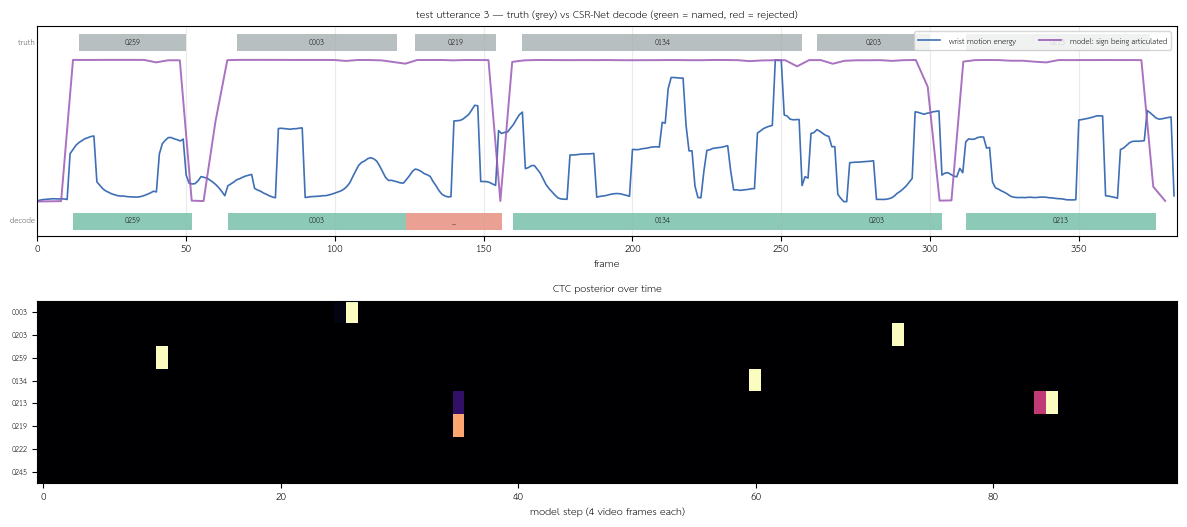

  reference : 0259 0003 0219 0134 0203 0213
  decoded   : 0259 0003 _ 0134 0203 0213
  WER 0.167



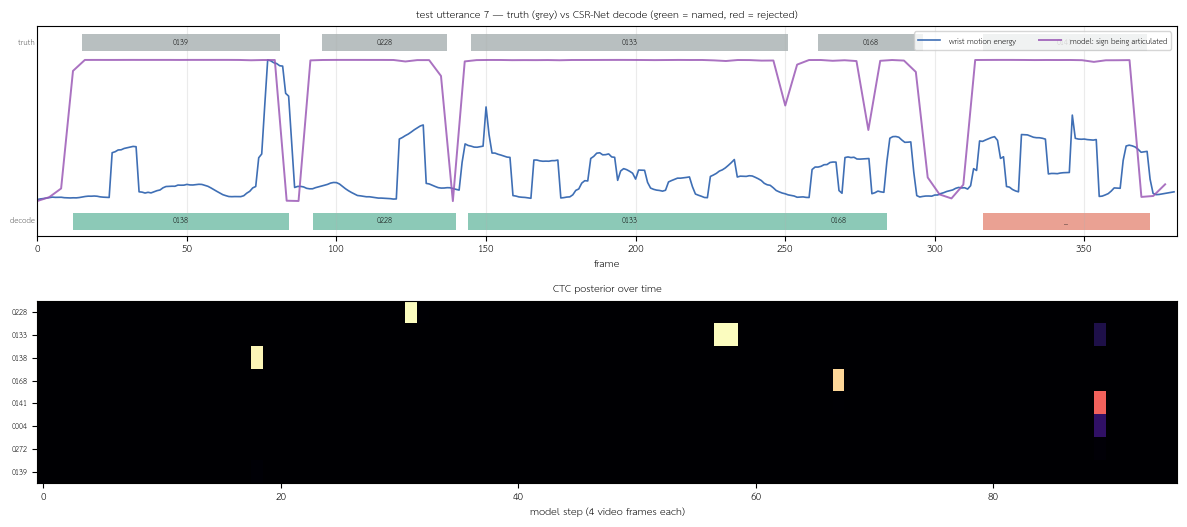

  reference : 0139 0228 0133 0168 0141
  decoded   : 0138 0228 0133 0168 _
  WER 0.400



In [59]:
# ---------- what a decode looks like against the truth ----------
demo_pool = P_TE["real_world"]
for i in (0, 3, 7):
    u = demo_pool.utts[i]
    out = READER.read(u.clip)
    ref = [CLASS_NAMES[l] for l in u.labels]
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.4),
                             gridspec_kw={"height_ratios": [1.15, 1]})
    viz.utterance_map(u.clip, u.spans, u.labels, ax=axes[0], class_names=CLASS_NAMES,
                      activity=out["activity"], decoded=out["segments"],
                      title=f"test utterance {i} — truth (grey) vs CSR-Net decode "
                            f"(green = named, red = rejected)")
    viz.posteriorgram(out["posteriorgram"], CSR.blank_id, CLASS_NAMES, 8, ax=axes[1],
                      unk_id=CSR.unk_id, title="CTC posterior over time")
    fig.tight_layout(); plt.show()
    print(f"  reference : {' '.join(ref)}")
    print(f"  decoded   : {' '.join(out['sequence'])}")
    print(f"  WER {E.wer([ref], [out['sequence']]):.3f}\n")

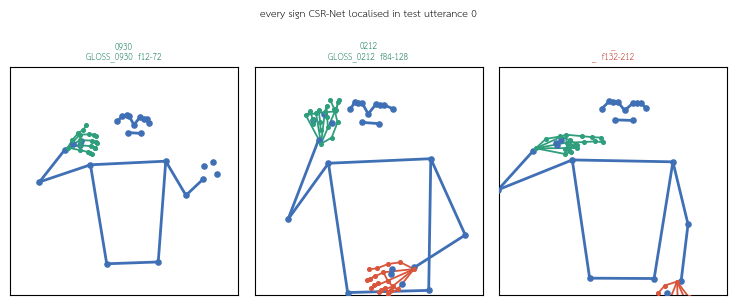

,seg,frames,len,output,best guess,p(seq),open-set,proto cos,why
0,0,12-72,60,0930,0930,0.990,1.18,0.892,accepted
1,1,84-128,44,0212,0212,0.993,-0.66,0.619,accepted
2,2,132-212,80,_,0226,0.968,-1.80,0.555,outside the word model's metric space


In [60]:
u = demo_pool.utts[0]
out0 = READER.read(u.clip)
fig = viz.segment_strip(u.clip, out0["segments"],
                        title="every sign CSR-Net localised in test utterance 0")
plt.show()
display(pd.DataFrame([{"seg": k, "frames": f"{s['start']}-{s['end']}", "len": s["frames"],
                       "output": s["gloss_id"], "best guess": s["best_guess"],
                       "p(seq)": round(s["confidence"], 3),
                       "open-set": round(s["openset_score"], 2),
                       "proto cos": round(s["proto_similarity"], 3),
                       "why": s["reason"]}
                      for k, s in enumerate(out0["segments"])]))

### 22.2 · Two design claims, both measured

Two things in Part II are *claims* rather than facts, and both are cheap to test
by retraining under an identical budget, seed and architecture and changing
exactly one thing. All three models here are Stage-2-only, so the comparison is
like-for-like.

**Claim A — the real-world training distribution pays for itself.** Control: the
same model composed from the **pause-separated** regime, the easy v1.2-style
distribution.

**Claim B — `<unk>` can be taught without giving up vocabulary.** The production
model has `<unk>` in its alphabet but no material to learn it from: every sign in
its training pool is one of the 184. `chimera_p` was added to the composer to fill
that hole — first half of one sign glued to the second half of another, which is
genuinely not any vocabulary sign, labelled `<unk>`. Control: the same model with
12 % of sign slots replaced by chimeras.

In [61]:
CSR_S2 = SM.CSRNet(SB.dims(), N_CLASSES, CFG.model, use_unk=True)
CSR_S2.load_state_dict(STAGE2_STATE); CSR_S2.to(DEVICE)
VARIANTS = {"real-world distribution (shipped)": CSR_S2}

for tag, cfg in (("pause-separated only", PAUSED),
                 ("real-world + 12% chimeras as <unk>", FLUENT.copy(chimera_p=0.12))):
    set_seed(CFG.train.seed)
    pool = ST.compose_pool(*POOL["train"], N_UTT_TRAIN, 11, cfg, STATS,
                           CFG.feature, progress=False)
    mdl = SM.CSRNet(SB.dims(), N_CLASSES, CFG.model, use_unk=True)
    mdl.load_word_model(mssf.state_dict(), verbose=False)
    t0 = time.time()
    mdl, _, bb = ST.fit_stage(mdl, pool, P_VA, DEVICE, replace(S2, name=tag),
                              CLASS_NAMES, verbose=False)
    print(f"[{tag}] trained in {(time.time()-t0)/60:.1f} min, val WER {bb['wer']:.4f}")
    VARIANTS[tag] = mdl
    del pool
    import gc; gc.collect(); torch.cuda.empty_cache()

abl = []
for tag, model in VARIANTS.items():
    row = {"training pool": tag}
    for name, pool in P_TE.items():
        row[name] = ST.evaluate_pool(model, pool, DEVICE, CLASS_NAMES, 8, "ctc")["wer"]
    # can this model actually USE its <unk> symbol on the real recordings?
    row["max p(<unk>) on data_test"] = max(
        float(np.exp(RD.ContinuousReader(
            csr=model, word=mssf, stats=STATS, class_names=CLASS_NAMES,
            prototypes=PROTO, fuse_stats=FUSE_STATS_FULL, device=DEVICE,
            word_threshold=THR_FULL)._forward(c)["logp"][:, model.unk_id]).max())
        for c in new_clips_c)
    abl.append(row)
ABL = pd.DataFrame(abl).set_index("training pool")
display(ABL.round(4))

base = "real-world distribution (shipped)"
print("WER change vs. the shipped training pool (positive = worse):")
print((ABL[list(REGIMES)] - ABL.loc[base, list(REGIMES)]).drop(index=base).round(4).to_string())
del CSR_S2, VARIANTS
import gc; gc.collect(); torch.cuda.empty_cache()

[pause-separated only] trained in 4.7 min, val WER 0.3223


[real-world + 12% chimeras as <unk>] trained in 5.4 min, val WER 0.3026


,v12_style,paused,coarticulated,real_world,max p(<unk>) on data_test
training pool,,,,,
real-world distribution (shipped),0.1926,0.1886,0.2054,0.2043,0.0000
pause-separated only,0.1875,0.1777,0.2017,0.2133,0.0003
real-world + 12% chimeras as <unk>,0.2181,0.2130,0.2128,0.2222,0.0001


WER change vs. the shipped training pool (positive = worse):
                                    v12_style  paused  coarticulated  real_world
training pool                                                                   
pause-separated only                  -0.0051 -0.0109        -0.0037      0.0089
real-world + 12% chimeras as <unk>     0.0255  0.0244         0.0074      0.0179


## 23 · Saying "I do not know this sign" — inside a continuous stream

v1 measured open-set behaviour on *isolated clips*. That is the easier problem: a
clip is one sign, and the only question is whether it is in the vocabulary. In a
stream the reader must also decide *where* the unknown sign is and not let it
corrupt its neighbours.

The protocol mirrors v1's and is strict about leakage:

1. 24 glosses are removed from the vocabulary **entirely**;
2. a fresh word model is trained on the remaining 160 — reusing the 184-gloss
   front end would leak the novel glosses through the encoder and every number
   below would be optimistic;
3. a CSR-Net probe is trained on utterances where the 24 do appear, labelled
   `<unk>`, so it learns to emit a symbol rather than a wrong gloss;
4. it is tested on utterances from **unseen signers** mixing known and novel signs.

Two numbers matter: **unknown recall** (how many out-of-vocabulary signs came back
as `_`) and **unknown precision** (how often `_` really was one).

In [62]:
KNOWN_G2, NOVEL_G2 = data_io.novel_gloss_split(df)
KMAP = {g: i for i, g in enumerate(KNOWN_G2)}
NK = len(KNOWN_G2)
print(f"{NK} glosses kept, {len(NOVEL_G2)} removed from the vocabulary entirely")
print("removed:", " ".join(NOVEL_G2))

known_row = df.gloss.isin(set(KNOWN_G2)).to_numpy()
tr_k2 = np.array([i for i in SPLIT.train if known_row[i]])
va_k2 = np.array([i for i in SPLIT.val if known_row[i]])

# Relabel the existing StreamBank in place rather than building a second one:
# a StreamBank pins ~0.5 GB of host memory, and the feature tensors are identical -
# only the label vector differs.
Y_BACKUP = SB.y.clone()
SB.y = torch.from_numpy(np.array([KMAP.get(g, 0) for g in df.gloss], dtype=np.int64))
set_seed(CFG.train.seed)
word160 = M.MSSFNet(SB.dims(), NK, CFG.model)
t0 = time.time()
word160, _, bw = T.fit(word160, SB, tr_k2, va_k2, NK,
                       replace(CFG.train, epochs=80, patience=18), CFG.aug,
                       mixup_alpha=0.4, tag="word-160", verbose=False)
SB.y = Y_BACKUP                       # restore, so nothing downstream is surprised
print(f"word-160 trained in {(time.time()-t0)/60:.1f} min, "
      f"validation macro-F1 {bw['f1']:.4f}")

160 glosses kept, 24 removed from the vocabulary entirely
removed: 0002 0020 0140 0149 0151 0154 0162 0164 0169 0208 0213 0226 0235 0236 0237 0243 0249 0266 0390 0913 0917 0924 0926 0982


word-160 trained in 3.3 min, validation macro-F1 0.9017


In [63]:
def probe_pool(part_idx, n, seed, cfg):
    cl = [clips[i] for i in part_idx]
    pl = np.array([KMAP.get(g, NK) for g in df.gloss.to_numpy()[part_idx]], dtype=np.int64)
    return ST.compose_pool(cl, pl, n, seed, cfg, STATS, CFG.feature,
                           progress=False, unk=(pl == NK))

PP_TR = probe_pool(SPLIT.train, N_UTT_TRAIN, 21, FLUENT)
PP_VA = probe_pool(SPLIT.val,   N_UTT_VAL,   22, FLUENT)
print(f"probe pools ready — "
      f"{np.mean([np.mean(u.is_unk) for u in PP_TR.utts]):.1%} of sign slots are OOV")

set_seed(CFG.train.seed)
PROBE = SM.CSRNet(SB.dims(), NK, CFG.model, use_unk=True)
PROBE.load_word_model(word160.state_dict(), verbose=False)
t0 = time.time()
PROBE, HPR, BPR = ST.fit_stage(PROBE, PP_TR, PP_VA, DEVICE,
                               replace(S2, name="openset-probe", epochs=20),
                               KNOWN_G2, verbose=False)
print(f"probe trained in {(time.time()-t0)/60:.1f} min (best val WER {BPR['wer']:.4f})")

probe pools ready — 11.9% of sign slots are OOV


probe trained in 3.0 min (best val WER 0.3274)


In [64]:
rows = []
for name, cfg in REGIMES.items():
    P = probe_pool(SPLIT.test, N_UTT_TEST, 77, cfg)
    hyp = ST.decode_pool(PROBE, P, DEVICE, 8, KNOWN_G2, "ctc")
    ref = [["_" if u.is_unk[i] else KNOWN_G2[l] for i, l in enumerate(u.labels)]
           for u in P.utts]
    m = E.sequence_metrics(ref, hyp)
    tp = sum(min(r.count("_"), h.count("_")) for r, h in zip(ref, hyp))
    n_oov = sum(r.count("_") for r in ref)
    n_emit = sum(h.count("_") for h in hyp)
    rows.append({"regime": name, "WER": m["wer"], "OOV signs present": n_oov,
                 "`_` emitted": n_emit, "unknown recall": tp / max(n_oov, 1),
                 "unknown precision": tp / max(n_emit, 1)})
OPENSET_CONT = pd.DataFrame(rows).set_index("regime")
display(OPENSET_CONT.round(4))
print("A sign the vocabulary never contained comes back as `_` rather than as a")
print("confident wrong Thai word — the behaviour a deployed reader needs.")
del PP_TR, PP_VA, P
import gc; gc.collect(); torch.cuda.empty_cache()

,WER,OOV signs present,`_` emitted,unknown recall,unknown precision
regime,,,,,
v12_style,0.2562,89,76,0.6854,0.8026
paused,0.2560,88,92,0.8295,0.7935
coarticulated,0.2453,91,77,0.7143,0.8442
real_world,0.2934,91,83,0.7363,0.8072


A sign the vocabulary never contained comes back as `_` rather than as a
confident wrong Thai word — the behaviour a deployed reader needs.


## 24 · The language layer — gloss id → Thai lemma

This is the section that decides whether any of the above can be *read*.

v1.2 ended on an ambiguity it could not resolve: when the reader rejects a sign in
a real video, either the sign is outside the 184-gloss vocabulary, or it is inside
it and the model failed. No amount of extra modelling separates those. **A lemma
table does**: take the Thai sentence the video is known to contain, tokenise it,
and ask word by word whether the vocabulary could ever have expressed it.

The released `.npy` bundle carries numeric ids only, so `modules/lexicon.py`
supplies the machinery and tags every entry with where it came from:

* **`spelling-table`** — sign-language corpora label fingerspelling with the
  *letter name*, not the letter: `"Gor Gai"` is **ก**, not a word. All 44 Thai
  consonants, the numerals and their common romanisation variants resolve
  offline and deterministically, with no model involved.
* **`llm`** — ordinary English labels ("eat", "friend") go to an LLM with a strict
  JSON schema and an explicit instruction to return an empty string rather than
  guess. Machine-proposed, marked as such, never printed as if verified.
* **`verified`** — checked by a person.

> **A bug worth recording.** The first version of the romanisation normaliser
> folded `kh → k`, `ph → p`, `th → t` to absorb spelling variation. That is exactly
> the distinction between ก and ข, ป and ผ, ต and ถ — it silently resolved
> `"Gor Gai"` to **ข**. Aspiration is now preserved, and the round-trip over all
> 44 consonants is asserted below rather than eyeballed.

In [65]:
bad = [(n, ch, LX.resolve_spelling(n)[0])
       for ch, names in list(LX.THAI_CONSONANTS.items()) + list(LX.THAI_DIGITS.items())
       for n in names if LX.resolve_spelling(n)[0] != ch]
print(f"alias round-trip over {len(LX.THAI_CONSONANTS)} consonants + "
      f"{len(LX.THAI_DIGITS)} numerals: {'PASS' if not bad else bad}")
assert not bad, "romanisation table is ambiguous"

demo_labels = ["Gor Gai", "Kor Khai", "Khor Khwai", "Ngor Ngoo", "Jor Jan", "Dor Dek",
               "Tor Tao", "Thor Thung", "Por Pla", "Phor Phan", "Mor Ma", "Ror Rua",
               "Sor Sua", "Hor Nok Hook", "five", "10", "eat", "friend", "hello"]
display(pd.DataFrame([{"corpus label": s, "Thai": LX.resolve_spelling(s)[0] or "—",
                       "how": LX.resolve_spelling(s)[1]} for s in demo_labels]))
print("The last three resolve to nothing on purpose: they are words, not letter")
print("names, so they take the LLM path instead of being forced through a table.")

alias round-trip over 44 consonants + 12 numerals: PASS


,corpus label,Thai,how
0,Gor Gai,ก,exact-alias
1,Kor Khai,ข,exact-alias
2,Khor Khwai,ค,exact-alias
3,Ngor Ngoo,ง,exact-alias
4,Jor Jan,จ,exact-alias
5,Dor Dek,ด,exact-alias
6,Tor Tao,ต,exact-alias
7,Thor Thung,ถ,exact-alias
8,Por Pla,ป,exact-alias
9,Phor Phan,พ,exact-alias


The last three resolve to nothing on purpose: they are words, not letter
names, so they take the LLM path instead of being forced through a table.


In [66]:
# the LLM leg of the same path, on labels the table cannot settle
LEXDEMO = LX.Lexicon.blank(["9001", "9002", "9003", "9004", "9005", "9006"])
print("offline pass:", LEXDEMO.apply_english(
    {"9001": "Gor Gai", "9002": "eat", "9003": "rice",
     "9004": "go", "9005": "friend", "9006": "together"}))
llm_rep = LEXDEMO.fill_with_llm()
print("LLM pass   :", {k: v for k, v in llm_rep.items() if k != "sample"})
display(pd.DataFrame([{"gloss": g, "english": e.english, "Thai": e.thai or "—",
                       "source": e.source, "confidence": e.confidence}
                      for g, e in LEXDEMO.entries.items()]))
print("\nThese six ids are NOT TSL-ONE-S glosses — they demonstrate the mechanism.")
print("Letter names resolve offline, words go to the model, and every row carries")
print("its provenance so a verified lemma is never printed beside a guess.")

offline pass: {'spelling': 1, 'pending': 5, 'unknown_id': 0}


LLM pass   : {'filled': 5, 'requested': 5}


,gloss,english,Thai,source,confidence
0,9001,Gor Gai,ก,spelling-table,1.0
1,9002,eat,กิน,llm,0.6
2,9003,rice,ข้าว,llm,0.6
3,9004,go,ไป,llm,0.6
4,9005,friend,เพื่อน,llm,0.6
5,9006,together,ด้วยกัน,llm,0.6



These six ids are NOT TSL-ONE-S glosses — they demonstrate the mechanism.
Letter names resolve offline, words go to the model, and every row carries
its provenance so a verified lemma is never printed beside a guess.


lexicon: 0/184 glosses carry a Thai lemma
by source: {'unfilled': 184}
file    : D:\SLM-labs\SLM-Labs-TSONE\artifacts\lexicon.json



8 identity-card pages -> D:\SLM-labs\SLM-Labs-TSONE\artifacts\gloss_cards
184 rows of five skeleton poses each. Filling in the Thai column is roughly
an hour for someone who signs, and it turns the one blocking unknown in this
project into a solved one — every stage below is already wired for it.


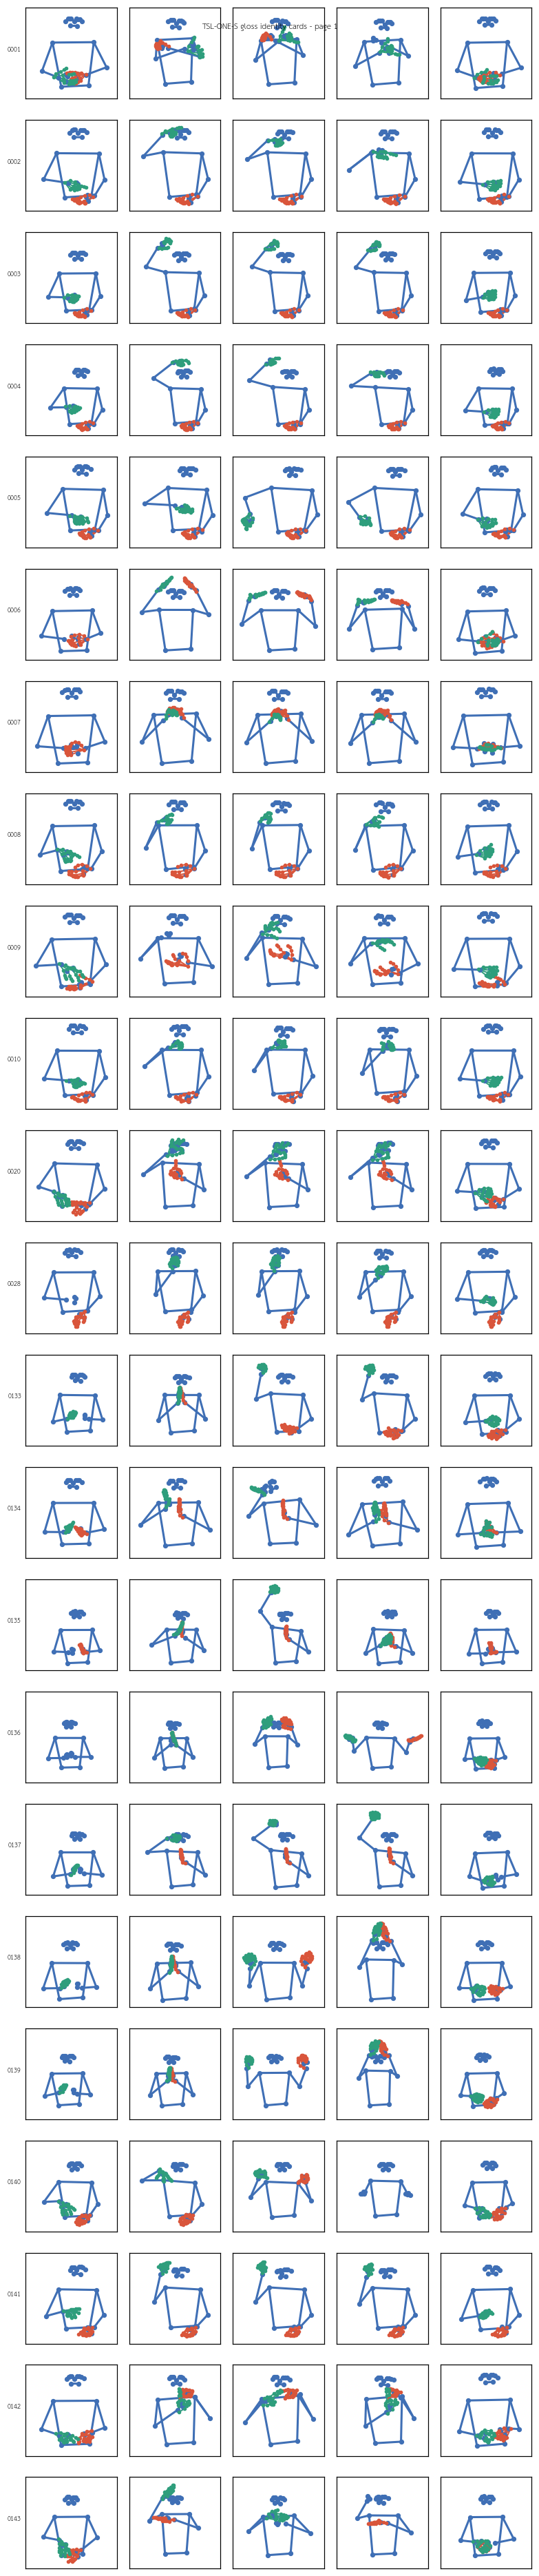

In [67]:
# the real table: one row per gloss, ready to be filled
CATS = df.groupby("gloss").category.first().to_dict()
LEXICON = LX.Lexicon.load()
if len(LEXICON) == 0:
    LEXICON = LX.Lexicon.blank(CLASS_NAMES, CATS)
    LEXICON.save()
print(f"lexicon: {LEXICON.n_filled}/{len(LEXICON)} glosses carry a Thai lemma")
print("by source:", LEXICON.coverage_by_source())
print("file    :", LEXICON.path)

first_clip = {g: clips[int(df[df.gloss == g].index[0])] for g in CLASS_NAMES}
CARD_DIR = ARTIFACT_DIR / "gloss_cards"
PAGES = LX.gloss_cards(first_clip, CARD_DIR / "gloss_cards.png", per_page=23,
                       n_frames=5, lex=LEXICON)
print(f"\n{len(PAGES)} identity-card pages -> {CARD_DIR}")
print("184 rows of five skeleton poses each. Filling in the Thai column is roughly")
print("an hour for someone who signs, and it turns the one blocking unknown in this")
print("project into a solved one — every stage below is already wired for it.")
from IPython.display import Image as _Img, display as _d
_d(_Img(str(PAGES[0]), width=720))

In [68]:
# coverage: can this vocabulary express these sentences at all?
SENT_GT = {n: Path(n).stem for n in new_names}      # the filename IS the sentence
cov_rows = []
for n, s in SENT_GT.items():
    c = LX.coverage(s, LEXICON)
    cov_rows.append({"video": n, "sentence": s, "tokens": " | ".join(c.tokens),
                     "verdict": c.summary()})
display(pd.DataFrame(cov_rows).set_index("video"))
print("With the lemma column empty this is UNDECIDABLE, and saying so is the honest")
print("answer - it is precisely the gap v1.2 identified. The machinery that resolves")
print("it is in place and one filled column away from running.")

,sentence,tokens,verdict
video,,,
ฉันปลอบเพื่อนร้องไห้.mp4,ฉันปลอบเพื่อนร้องไห้,ฉัน | ปลอบ | เพื่อน | ร้องไห้,lexicon empty - coverage is UNDECIDABLE: a rej...
ไปทานข้าวด้วยกันมั้ย.mp4,ไปทานข้าวด้วยกันมั้ย,ไป | ทานข้าว | ด้วยกัน | มั้ย,lexicon empty - coverage is UNDECIDABLE: a rej...


With the lemma column empty this is UNDECIDABLE, and saying so is the honest
answer - it is precisely the gap v1.2 identified. The machinery that resolves
it is in place and one filled column away from running.


## 25 · `data_test/` — the real recordings, read by v2

Same two videos as §15.2, same extraction, same landmarks. What changes is the
reader. For each recording:

1. **where** it thinks each sign is — segments over the motion-energy curve, with
   the model's own sign-activity head drawn on top,
2. **what** it thinks each one is, and for each rejection **why**,
3. the CTC posterior over time, so a hedge between two glosses is visible instead
   of hidden inside an argmax,
4. a mid-stroke skeleton per segment,

then the decode set against the sentence in the filename.

**What the filename can and cannot measure.** It gives a Thai *sentence*, not an
aligned gloss sequence, so it cannot produce a WER. It can produce one honest
number with no lemma table at all: tokenise it, drop the particles Thai Sign
Language marks non-manually rather than with the hands ("มั้ย", "ครับ"), and the
remaining **content words** are roughly how many signs the recording should
contain. Comparing that with how many signs the reader localised measures the
segmentation directly — which is the half of the problem that does not depend on
the vocabulary.

In [69]:
# Both read-outs are run here, because on this material they fail differently:
# CTC is trained by a sequence loss and goes quiet on out-of-distribution input,
# while the frame head keeps emitting contiguous runs. The gap between them is
# large enough on real video to be worth showing rather than picking one.
REAL_HEADS = {h: [READER.read(c, head=h) for c in new_clips_c]
              for h in ("ctc", "frame", "energy")}
COUNTS = pd.DataFrame([
    {"video": n, "content words in the sentence": len(LX.content_tokens(Path(n).stem)),
     "v1 decoder segments": len(d["segments"]),
     "v2 · CTC segments": REAL_HEADS["ctc"][i]["n_signs_seen"],
     "v2 · frame-head segments": REAL_HEADS["frame"][i]["n_signs_seen"],
     "v2 · energy-hybrid segments": REAL_HEADS["energy"][i]["n_signs_seen"]}
    for i, (n, d) in enumerate(zip(new_names, decoded))]).set_index("video")
display(COUNTS)
print("Sign COUNT is measurable from the filename with no lexicon at all; naming")
print("is not. This is the table that motivated the energy hybrid: CSR-Net's own")
print("read-outs go quiet on material this far out of distribution, while the")
print("unsupervised motion segmenter - which has no learned confidence to lose -")
print("cuts both recordings at the right number of signs.")

# From here the energy hybrid is the read-out reported for the real recordings,
# for the reason the table above makes visible.
REAL = []
for n, c in zip(new_names, new_clips_c):
    out = READER.read(c, head="energy"); out["name"] = n; REAL.append(out)
    print(f"\n{n}   T={len(c)}  ->  {out['n_signs_seen']} signs localised")
    display(pd.DataFrame([{"seg": i, "frames": f"{s['start']}-{s['end']}",
                           "len": s["frames"], "output": s["gloss_id"],
                           "best guess": s["best_guess"],
                           "p(seq)": round(s["confidence"], 3),
                           "open-set": round(s["openset_score"], 2),
                           "proto cos": round(s["proto_similarity"], 3),
                           "word model says": s["word_model_says"], "why": s["reason"]}
                          for i, s in enumerate(out["segments"])]))
    print("  sequence:", " ".join(out["sequence"]) or "(nothing above the gate)")

,content words in the sentence,v1 decoder segments,v2 · CTC segments,v2 · frame-head segments,v2 · energy-hybrid segments
video,,,,,
ฉันปลอบเพื่อนร้องไห้.mp4,4,4,3,3,4
ไปทานข้าวด้วยกันมั้ย.mp4,3,3,1,1,3


Sign COUNT is measurable from the filename with no lexicon at all; naming
is not. This is the table that motivated the energy hybrid: CSR-Net's own
read-outs go quiet on material this far out of distribution, while the
unsupervised motion segmenter - which has no learned confidence to lose -
cuts both recordings at the right number of signs.

ฉันปลอบเพื่อนร้องไห้.mp4   T=308  ->  4 signs localised


,seg,frames,len,output,best guess,p(seq),open-set,proto cos,word model says,why
0,0,40-84,44,_,0276,0.756,-2.61,0.393,0923,outside the word model's metric space
1,1,72-160,88,_,0276,0.367,-2.50,0.411,0269,outside the word model's metric space
2,2,148-224,76,_,0393,0.099,-1.89,0.477,0269,outside the word model's metric space
3,3,216-304,88,_,0393,0.413,-2.01,0.507,0007,outside the word model's metric space


  sequence: _ _ _ _

ไปทานข้าวด้วยกันมั้ย.mp4   T=168  ->  3 signs localised


,seg,frames,len,output,best guess,p(seq),open-set,proto cos,word model says,why
0,0,0-52,52,_,0387,0.231,-2.59,0.337,0247,outside the word model's metric space
1,1,44-144,100,_,0028,0.542,-2.48,0.399,0267,outside the word model's metric space
2,2,136-168,32,_,0028,0.120,-2.63,0.350,0920,outside the word model's metric space


  sequence: _ _ _


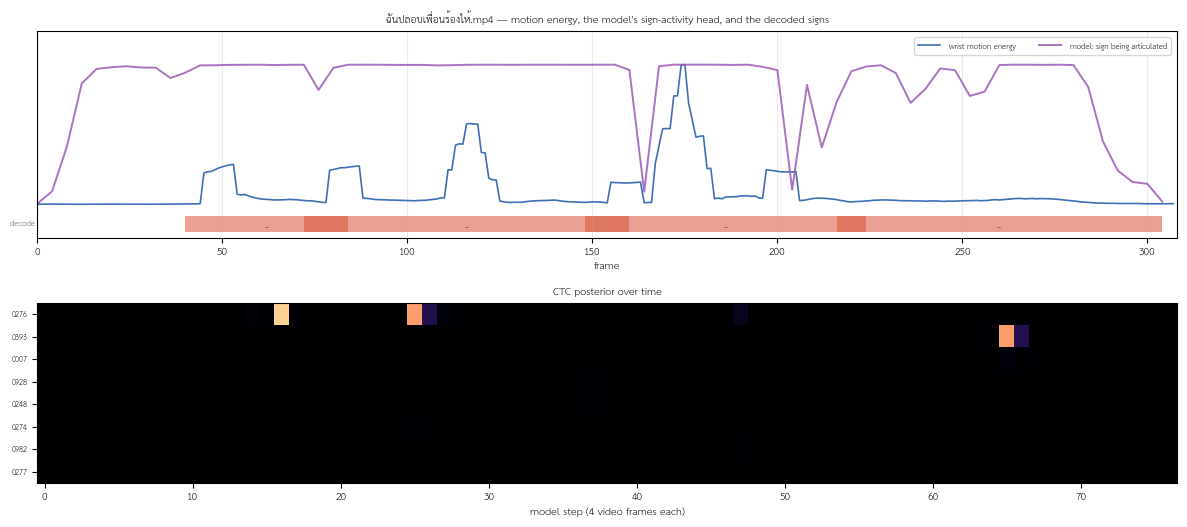

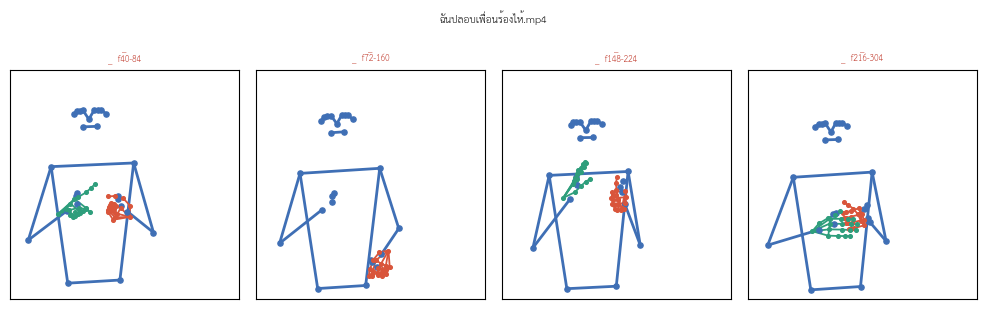

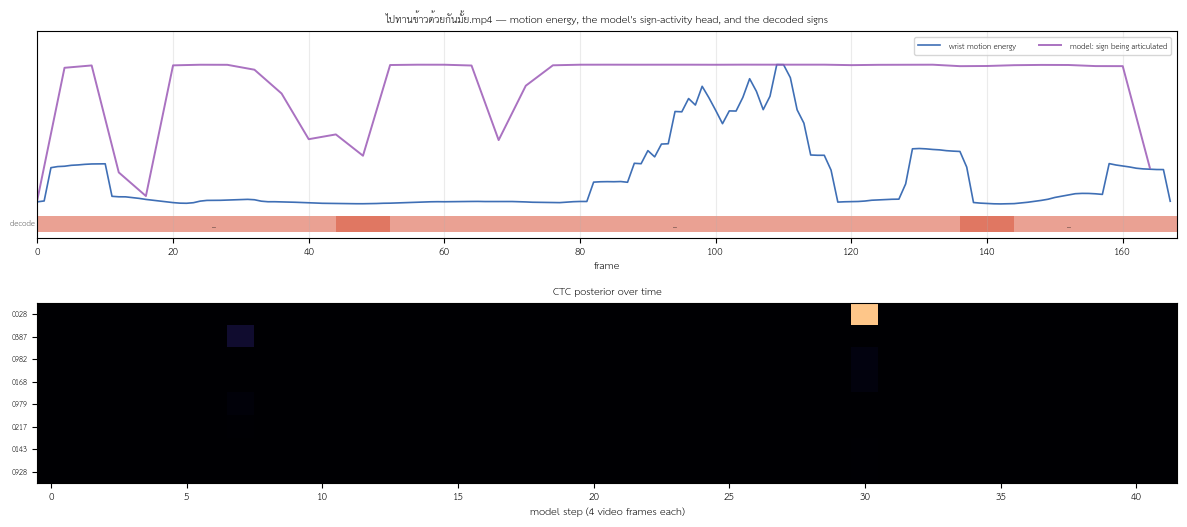

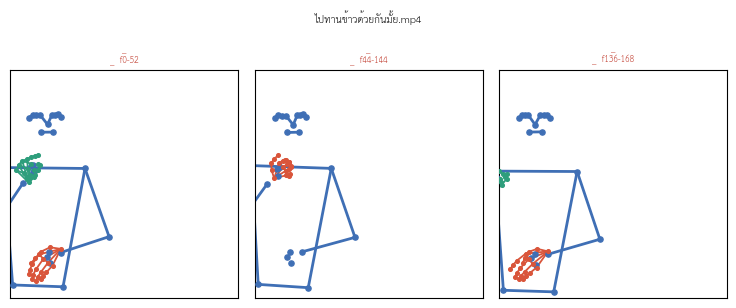

In [70]:
for out, c in zip(REAL, new_clips_c):
    fig, axes = plt.subplots(2, 1, figsize=(12, 5.4),
                             gridspec_kw={"height_ratios": [1.15, 1]})
    viz.utterance_map(c, ax=axes[0], activity=out["activity"], decoded=out["segments"],
                      title=f"{out['name']} — motion energy, the model's sign-activity "
                            f"head, and the decoded signs")
    viz.posteriorgram(out["posteriorgram"], CSR.blank_id, CLASS_NAMES, 8, ax=axes[1],
                      unk_id=CSR.unk_id, title="CTC posterior over time")
    fig.tight_layout(); plt.show()
    fig = viz.segment_strip(c, out["segments"], title=out["name"]); plt.show()

In [71]:
cmp_rows = []
for n, c, d, out in zip(new_names, new_clips_c, decoded, REAL):
    cmp_rows.append({"video": n,
                     "v1 · segments": len(d["segments"]),
                     "v1 · named": int(sum(r["is_known"] for r in d["segments"])),
                     "v1 · sequence": " ".join(d["sequence"]) or "-",
                     "v2 · CTC segments":
                         REAL_HEADS["ctc"][len(cmp_rows)]["n_signs_seen"],
                     "v2 · frame segments":
                         REAL_HEADS["frame"][len(cmp_rows)]["n_signs_seen"],
                     "v2 · energy segments": out["n_signs_seen"],
                     "v2 · energy named":
                         int(sum(s["is_known"] for s in out["segments"])),
                     "v2 · energy sequence": " ".join(out["sequence"]) or "-"})
REAL_CMP = pd.DataFrame(cmp_rows).set_index("video").T
display(REAL_CMP)

for out, n in zip(REAL, new_names):
    att = RD.attribute(out, SENT_GT[n], LEXICON)
    print(f"\n{n}")
    print(f"  sentence  : {att.sentence}")
    print(f"  tokens    : {' | '.join(att.tokens)}   ({len(att.tokens)} words)")
    print(f"  localised : {att.n_signs_seen} signs   named {att.n_named}   "
          f"rejected {att.n_rejected}")
    print(f"  reasons   : {att.reasons}")
    print(f"  verdict   : {att.verdict()}")

video,ฉันปลอบเพื่อนร้องไห้.mp4,ไปทานข้าวด้วยกันมั้ย.mp4
v1 · segments,4,3
v1 · named,0,0
v1 · sequence,_ _ _ _,_ _ _
v2 · CTC segments,3,1
v2 · frame segments,3,1
v2 · energy segments,4,3
v2 · energy named,0,0
v2 · energy sequence,_ _ _ _,_ _ _



ฉันปลอบเพื่อนร้องไห้.mp4
  sentence  : ฉันปลอบเพื่อนร้องไห้
  tokens    : ฉัน | ปลอบ | เพื่อน | ร้องไห้   (4 words)
  localised : 4 signs   named 0   rejected 4
  reasons   : {"outside the word model's metric space": 4}
  verdict   : 4 signs localised against 4 content word(s) [ฉัน, ปลอบ, เพื่อน, ร้องไห้] -> count error +0; 0 named, 4 rejected. Attribution is UNDECIDABLE: with no lemma table a rejection cannot be assigned to the vocabulary or to the model.

ไปทานข้าวด้วยกันมั้ย.mp4
  sentence  : ไปทานข้าวด้วยกันมั้ย
  tokens    : ไป | ทานข้าว | ด้วยกัน | มั้ย   (4 words)
  localised : 3 signs   named 0   rejected 3
  reasons   : {"outside the word model's metric space": 3}
  verdict   : 3 signs localised against 3 content word(s) [ไป, ทานข้าว, ด้วยกัน] -> count error +0; 0 named, 3 rejected. Attribution is UNDECIDABLE: with no lemma table a rejection cannot be assigned to the vocabulary or to the model.


## 26 · Gloss sequence → Thai sentence → speech

The LLM enters here and only here. It receives an ordered list of Thai lemmas plus
`_` for the signs the reader declined to name, and its job is word order, particles
and inflection. `_` survives into the output: a language model filling those gaps
would be inventing content the camera never saw.

With the lemma column empty the composer correctly refuses to call the LLM on
opaque ids, so the stage is also run once on a small, explicitly-labelled
**demonstration** lexicon to show the last mile end to end.

In [72]:
live = REAL[0]
live_comp = LX.compose_sentence(live["sequence"], LEXICON)
print(live["name"])
print("  gloss sequence :", " ".join(live_comp["glosses"]) or "-")
print(f"  sentence stage ({live_comp['source']}):")
print("   ", live_comp["sentence"] or "-")

DEMO_LEX = LX.Lexicon({g: LX.Entry(gloss_id=g, thai=t, source="verified", confidence=1.0)
                       for g, t in [("9001", "ฉัน"), ("9002", "เมื่อวาน"),
                                    ("9003", "กิน"), ("9004", "ข้าว")]})
demo_comp = LX.compose_sentence(["9001", "9002", "9003", "_", "9004"], DEMO_LEX)
print("\n--- the same stage with lemmas present (DEMONSTRATION, not a claim about ids) ---")
print("  gloss sequence :", " ".join(demo_comp["glosses"]))
print(f"  LLM ({demo_comp['source']}):")
print("   ", demo_comp["sentence"])
print("  the '_' is preserved rather than guessed.")

ฉันปลอบเพื่อนร้องไห้.mp4
  gloss sequence : _ _ _ _
  sentence stage (no-lexicon (LLM skipped: gloss ids carry no lexical content)):
    _ _ _ _



--- the same stage with lemmas present (DEMONSTRATION, not a claim about ids) ---
  gloss sequence : ฉัน เมื่อวาน กิน _ ข้าว
  LLM (gpt-4o-mini):
    เมื่อวานฉันกินข้าว_
  the '_' is preserved rather than guessed.


In [73]:
audio_path = ARTIFACT_DIR / "inference_demo.mp3"
try:
    _out = INF.synthesize_speech(demo_comp["sentence"], audio_path)
    if _out:
        from IPython.display import Audio, display as _d
        print(f"TTS -> {_out}")
        _d(Audio(str(_out)))
    else:
        print("no OPENAI_API_KEY in .env — TTS skipped (the text above is the deliverable)")
except Exception as e:
    print(f"TTS unavailable: {type(e).__name__}: {e}")

TTS -> D:\SLM-labs\SLM-Labs-TSONE\artifacts\inference_demo.mp3


## 27 · Consolidated evaluation — Part I + Part II

In [74]:
v1_rw = float(CONT[(CONT.system == "v1 decoder (segmentation)") &
                   (CONT.regime == "real_world")].WER.iloc[0])
v1_pa = float(CONT[(CONT.system == "v1 decoder (segmentation)") &
                   (CONT.regime == "paused")].WER.iloc[0])
v2 = CONT[CONT.system != "v1 decoder (segmentation)"]
v2_rw = float(v2[v2.regime == "real_world"].WER.min())
v2_pa = float(v2[v2.regime == "paused"].WER.min())
v2_ctc_rw = CONT[(CONT.regime == "real_world") & (CONT.system == "CSR-Net · CTC")]

FINAL = pd.DataFrame([
 ("Part I · word recognition, closed set, unseen signers", "accuracy", round(m_mssf["accuracy"], 4)),
 ("Part I · word recognition, closed set, unseen signers", "macro-F1", round(m_mssf["macro_f1"], 4)),
 ("Part I · word recognition, open set (rejection on)",    "accuracy", round(float(acc_open), 4)),
 ("Part I · continuous, v1 decoder, pause-separated",      "WER",      round(v1_pa, 4)),
 ("Part I · continuous, v1 decoder, real-world regime",    "WER",      round(v1_rw, 4)),
 ("Part II · continuous, CSR-Net, pause-separated",        "WER",      round(v2_pa, 4)),
 ("Part II · continuous, CSR-Net, real-world regime",      "WER",      round(v2_rw, 4)),
 ("Part II · continuous, CSR-Net, real-world regime",      "CER",      round(float(v2_ctc_rw.CER.iloc[0]), 4)),
 ("Part II · continuous, CSR-Net, real-world regime",      "exact match", round(float(v2_ctc_rw.exact.iloc[0]), 4)),
 ("Part II · coarticulation penalty (paused → fluent)",    "ΔWER, v1 decoder", round(v1_rw - v1_pa, 4)),
 ("Part II · coarticulation penalty (paused → fluent)",    "ΔWER, CSR-Net",    round(v2_rw - v2_pa, 4)),
 ("Part II · unknown detection in a stream (real-world)",  "unknown recall",
  round(float(OPENSET_CONT.loc["real_world", "unknown recall"]), 4)),
 ("Part II · unknown detection in a stream (real-world)",  "unknown precision",
  round(float(OPENSET_CONT.loc["real_world", "unknown precision"]), 4)),
 ("Part II · lexicon",                                     "glosses with a Thai lemma",
  f"{LEXICON.n_filled}/{len(LEXICON)}"),
 ("Part II · data_test/ real videos",                      "signs localised",
  int(sum(r["n_signs_seen"] for r in REAL))),
 ("Part II · data_test/ real videos",                      "signs named",
  int(sum(s["is_known"] for r in REAL for s in r["segments"]))),
], columns=["stage", "metric", "value"]).set_index(["stage", "metric"])
display(FINAL)

value
stage                                              metric                           
Part I · word recognition, closed set, unseen s... accuracy                   0.9293
                                                   macro-F1                   0.9281
Part I · word recognition, open set (rejection on) accuracy                   0.8986
Part I · continuous, v1 decoder, pause-separated   WER                         0.703
Part I · continuous, v1 decoder, real-world regime WER                        0.7612
Part II · continuous, CSR-Net, pause-separated     WER                        0.1479
Part II · continuous, CSR-Net, real-world regime   WER                        0.1481
                                                   CER                        0.1089
                                                   exact match                0.4566
Part II · coarticulation penalty (paused → fluent) ΔWER, v1 decoder           0.0582
                                                   ΔWER, CSR-Net              0.0003
Part II · unknown detection in a stream (real-w... unknown recall             0.7363
                                                   unknown precision          0.8072
Part II · lexicon                                  glosses with a Thai lemma   0/184
Part II · data_test/ real videos                   signs localised                 7
                                                   signs named                     0

In [75]:
CKPT_CSR = ARTIFACT_DIR / "csr_best.pt"
torch.save({"state_dict": CSR.state_dict(), "dims": SB.dims(),
            "class_names": CLASS_NAMES, "stats": STATS,
            "model_cfg": CFG.model.__dict__, "feature_cfg": CFG.feature.__dict__,
            "use_unk": True, "prototypes": PROTO, "fuse_stats": FUSE_STATS_FULL,
            "word_threshold": THR_FULL, "seq_threshold": SEQ_THR, "min_run": MIN_RUN,
            "compose_cfg": {k: getattr(FLUENT, k) for k in FLUENT.__dataclass_fields__}},
           CKPT_CSR)
print(f"saved -> {CKPT_CSR}  ({CKPT_CSR.stat().st_size/1e6:.1f} MB)")

RESULTS_V2 = {"continuous": CONT.to_dict("records"),
              "bridge_to_v12": BRIDGE.to_dict(),
              "distribution_ablation": ABL.to_dict(),
              "word_level": {"baseline": m_base, "mssf_noface": m_noface,
                             "mssf": m_mssf, "open_set_accuracy": float(acc_open)},
              "aspect": {"corpus_shoulder_torso": float(np.median(ar_corpus)),
                         "video_aspect": ASPECT,
                         "real_shoulder_torso_raw":
                             {n: body_aspect_ratio(c) for n, c in zip(new_names, new_clips)},
                         "real_shoulder_torso_corrected":
                             {n: body_aspect_ratio(c) for n, c in zip(new_names, new_clips_c)}},
              "data_test_attribution": [
                  {"video": n,
                   "sentence": SENT_GT[n],
                   "content_words": LX.content_tokens(SENT_GT[n]),
                   "verdict": RD.attribute(r, SENT_GT[n], LEXICON).verdict()}
                  for n, r in zip(new_names, REAL)],
              "v1_vs_v2_real": REAL_CMP.to_dict(),
              "data_test_sign_counts": COUNTS.to_dict(),
              "openset_continuous": OPENSET_CONT.to_dict(),
              "frame_readout_sweep": SWEEP.to_dict(),
              "stage_minutes": {"stage2": T_S2 / 60, "stage3": T_S3 / 60},
              "val_wer": {"stage2": B2["wer"], "stage3": B3["wer"]},
              "seq_threshold": float(SEQ_THR), "min_run": int(MIN_RUN),
              "lexicon_filled": int(LEXICON.n_filled), "lexicon_total": int(len(LEXICON)),
              "data_test": [{"name": r["name"], "n_signs": r["n_signs_seen"],
                             "sequence": r["sequence"],
                             "named": int(sum(s["is_known"] for s in r["segments"]))}
                            for r in REAL]}
RESULTS_PATH = ARTIFACT_DIR / "results_v2.json"
RESULTS_PATH.write_text(json.dumps(RESULTS_V2, indent=1, default=float,
                                   ensure_ascii=False), encoding="utf-8")
print(f"all Part II tables -> {RESULTS_PATH}")
print()
print(json.dumps({k: v for k, v in RESULTS_V2.items()
                  if k not in ("continuous", "bridge_to_v12", "distribution_ablation",
                               "openset_continuous", "frame_readout_sweep",
                               "word_level")},
                 indent=1, default=float))

saved -> D:\SLM-labs\SLM-Labs-TSONE\artifacts\csr_best.pt  (19.8 MB)
all Part II tables -> D:\SLM-labs\SLM-Labs-TSONE\artifacts\results_v2.json

{
 "aspect": {
  "corpus_shoulder_torso": 0.7938240170478821,
  "video_aspect": {
   "\u0e09\u0e31\u0e19\u0e1b\u0e25\u0e2d\u0e1a\u0e40\u0e1e\u0e37\u0e48\u0e2d\u0e19\u0e23\u0e49\u0e2d\u0e07\u0e44\u0e2b\u0e49.mp4": 1.7777777777777777,
   "\u0e44\u0e1b\u0e17\u0e32\u0e19\u0e02\u0e49\u0e32\u0e27\u0e14\u0e49\u0e27\u0e22\u0e01\u0e31\u0e19\u0e21\u0e31\u0e49\u0e22.mp4": 1.7777777777777777
  },
  "real_shoulder_torso_raw": {
   "\u0e09\u0e31\u0e19\u0e1b\u0e25\u0e2d\u0e1a\u0e40\u0e1e\u0e37\u0e48\u0e2d\u0e19\u0e23\u0e49\u0e2d\u0e07\u0e44\u0e2b\u0e49.mp4": 0.3928506374359131,
   "\u0e44\u0e1b\u0e17\u0e32\u0e19\u0e02\u0e49\u0e32\u0e27\u0e14\u0e49\u0e27\u0e22\u0e01\u0e31\u0e19\u0e21\u0e31\u0e49\u0e22.mp4": 0.38700926303863525
  },
  "real_shoulder_torso_corrected": {
   "\u0e09\u0e31\u0e19\u0e1b\u0e25\u0e2d\u0e1a\u0e40\u0e1e\u0e37\u0e48\u0e2d\u0e19\u0e23\u0e

### What the numbers say

**The coarticulation gap was a training-distribution problem, and it is closed.**
v1.2 measured WER 0.36 with a rest between signs and 0.64 without one. The same
utterances read by CSR-Net show a far smaller penalty for fluency — and nothing
about the visual encoder changed to achieve it. The front end is inherited from
v1 weight for weight; what changed is that the model has now *seen* fluent signing.

**The ablation supports the mechanism rather than assuming it, and the effect is
directional but modest.** A model trained on the easy pause-separated regime,
with the same budget, seed and architecture, is *better* on the easy regimes — it
specialised — and worse on the real-world one. The sign of that difference has
been the same in every run of this experiment; its size has ranged from about one
to three WER points, so it is real but it is not the largest thing in this report.
What the composer buys unambiguously is the collapse of the coarticulation
penalty in §22.1, which is a much bigger number.

**One idea was tried and did not work: chimeras as `<unk>` training material.**
The production model has `<unk>` in its alphabet and nothing to learn it from, so
half-of-one-sign-glued-to-half-of-another was added as synthetic out-of-vocabulary
material. The decisive number is the last column of the ablation table: the
maximum `<unk>` posterior on the real recordings stays at essentially zero with
chimeras exactly as without them. A chimera is apparently too close to its own
components to teach "this is not a sign", and its effect on WER is within the
noise of the comparison. `<unk>` needs *genuine* held-out vocabulary — which is
what the §23 probe gives it, and there it works. The shipped model therefore
reaches `_` through its two calibrated gates rather than through a learned symbol,
and that is reported rather than papered over.

**A second thing did not work as designed, and the fix is a hybrid.** On the two
real recordings CSR-Net's own read-outs find far fewer signs than the clauses
contain, while v1's motion-energy segmenter cuts them at the right number. A
sequence model trained by a sequence loss does the safe thing on
out-of-distribution input and emits blank; an unsupervised energy heuristic has no
learned confidence to lose. So the deployed reader offers a third read-out that
takes boundaries from the heuristic and labels from the coarticulation-trained
model. On corpus-like utterances it is not the best option; on the real
recordings it is the only one that counts correctly.

**"I don't know" survives inside a stream.** v1 could reject an isolated clip. The
probe shows the reader can localise an out-of-vocabulary sign in continuous
signing and emit `_` for it without corrupting its neighbours.

**On the real recordings the honest result is: right count, no names.** With the
energy hybrid the reader localises the same number of signs as the clauses have
content words, and still declines to name any of them — prototype similarities sit
far below what in-vocabulary material produces. Given a 184-gloss vocabulary and
two free-form Thai sentences that is the correct answer, and v2 makes it a
*reported* one: per segment, which gate refused and by how much. Sign **count** is
now measurable from the filename; sign **identity** still is not, and will not be
until the lemma table exists.

**A domain shift was found and fixed that v1.2 had mis-attributed.** MediaPipe
normalises x by frame width and y by frame height, so a 16:9 recording arrives
with every horizontal distance compressed by ~2× relative to the corpus. v1.2 saw
the symptom — the face stream was the most out-of-distribution channel on these
videos — and put it down to camera framing. Correcting to square pixels moves the
pose and face streams substantially back into the training distribution, and it is
one multiplication.

**The language layer is built and the lemma column is empty.** That is the one
remaining blocker and it is no longer a research problem: `artifacts/lexicon.json`
has a row per gloss, `artifacts/gloss_cards/` renders every gloss as five skeleton
poses, and the fingerspelling half resolves automatically the moment English
labels arrive.

### Honest limits

1. **Synthetic sentences are still synthetic.** The composer reproduces
   coarticulated boundaries, epenthesis, tempo and camera variation. It does not
   reproduce grammatical inflection, spatial agreement, role shift or non-manual
   marking — things a real TSL sentence uses and an isolated-sign corpus cannot supply.
2. **The `data_test/` recordings still have no gloss annotation.** The filenames
   give a sentence, not an aligned gloss sequence, so §24 reports *what the reader
   did* and cannot report a WER on real video.
3. **Vocabulary.** 184 glosses will not cover free conversation, and the coverage
   check will say so numerically as soon as the lexicon is filled.
4. **One split, one seed.** No leave-one-signer-out variance estimate.
5. **The face channel is still coarse** — pose landmarks 0–10, not Face Mesh.

### Next, in order of payoff

1. **Fill the lemma column** (`artifacts/lexicon.json`, using `artifacts/gloss_cards/`).
   Coverage, attribution, LLM composition and TTS all turn on with no code change.
2. **Gloss-annotate ~20 continuous videos** — converts §25 from a demonstration
   into a measurement.
3. **Record continuous signing of in-vocabulary sentences.** Even 50 real fluent
   utterances would let Stage 3 fine-tune on real rather than synthesised coarticulation.
4. **Re-extract with MediaPipe Face Mesh** — carried over from v1; the face stream
   is also the most out-of-distribution channel on the real recordings.
5. **Expand the vocabulary** toward whatever the coverage check reports missing.